
# CDMX antes, durante y después del COVID-19
## Notebook 01 — Limpieza de datasets

Este notebook documenta **cómo se limpió cada fuente**: qué problemas se encontraron, qué se decidió y cuántos registros afectó cada paso. Ninguna celda modifica `data/raw/`; los resultados se guardan en `data/interim/` (CSV y Parquet).

| Sección | Dónde está el código de limpieza | Salidas en `data/interim/` |
|---|---|---|
| Semáforo epidemiológico | Este notebook | `semaforo_cdmx_semana` |
| Carpetas de investigación (FGJ) | `src/clean/fgj.py`, repetido paso a paso aquí | `fgj_carpetas`, `fgj_alcaldia_mes` |
| Afluencia del Metrobús | `src/clean/metrobus.py`, repetido paso a paso aquí | `metrobus_linea_dia`, `metrobus_mes` |
| Puestos de trabajo (IMSS) | Este notebook | `imss_subdelegacion_mes` |
| Ocupación hotelera | Este notebook | `hoteles_mes` |
| Hechos de tránsito (SSC) | Este notebook | `transito_alcaldia_mes`, `transito_alcaldia_dia` |
| Afluencia del Metro | Este notebook | `metro_linea_dia`, `metro_estacion_mes`, `metro_mes` |
| Casos COVID-19 | Este notebook | `covid_dia`, `covid_semana`, `covid_mes` |

**Criterio general:** en esta etapa los problemas se **marcan** (con columnas como `estado`, `mes_incompleto` o `valor_estimado`) y no se inventan datos. Completar o imputar huecos es un paso aparte, que todavía está pendiente.


---
## Semáforo epidemiológico (federal)

**Rol:** variable de control; indica qué restricciones estaban vigentes cada semana.

**Fuente:** `semaforos_federal.csv`, la compilación del paquete de R `semaforos`, porque no existe un dataset oficial descargable. Viene en formato **ancho**: una fila por entidad y una columna por semana ISO (`2020-W22`, `2020-W23`, …) con el color.

**Pasos de limpieza:**
1. Filtrar la CDMX.
2. Pasar a formato **largo** (una fila por semana) y agregar la fecha del lunes de cada semana.
3. Revisar faltantes (celdas vacías, semanas que no aparecen y colores válidos) y rellenar las 2 semanas que faltan.
4. Guardar.

### Paso 1 — Leer el archivo y filtrar la CDMX
El archivo tiene una fila por entidad federativa. Solo se conserva la de la Ciudad de México.

In [1]:
from pathlib import Path
import pandas as pd
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = RAIZ / "data" / "raw"
df = pd.read_csv(RAW / "semaforo" / "semaforos_federal.csv")
cdmx = df[df["estado"] == "Ciudad de México"]
cdmx

,estado,2020-W22,2020-W23,2020-W24,2020-W25,2020-W26,2020-W27,2020-W28,2020-W29,2020-W30,...,2023-W15,2023-W16,2023-W17,2023-W18,2023-W19,2023-W20,2023-W21,2023-W22,2023-W23,2023-W24
6,Ciudad de México,rojo,rojo,rojo,rojo,naranja,naranja,naranja,naranja,naranja,...,verde,verde,verde,verde,verde,verde,verde,verde,verde,verde


### Paso 2 — Formato largo y fecha de la semana
`melt` convierte cada columna de semana en una fila. La semana ISO (`2020-W22`) se convierte en la fecha de su **lunes** (formato `%G-W%V-%u` con día 1). Es la misma convención que usan los casos COVID (`covid_semana`), así que las dos fuentes se pueden unir directamente.

In [2]:
largo = cdmx.melt(id_vars="estado", var_name="semana", value_name="color")
largo["fecha"] = pd.to_datetime(largo["semana"] + "-1", format="%G-W%V-%u")
largo

,estado,semana,color,fecha
0,Ciudad de México,2020-W22,rojo,2020-05-25
1,Ciudad de México,2020-W23,rojo,2020-06-01
2,Ciudad de México,2020-W24,rojo,2020-06-08
3,Ciudad de México,2020-W25,rojo,2020-06-15
4,Ciudad de México,2020-W26,naranja,2020-06-22
...,...,...,...,...
153,Ciudad de México,2023-W20,verde,2023-05-15
154,Ciudad de México,2023-W21,verde,2023-05-22
155,Ciudad de México,2023-W22,verde,2023-05-29
156,Ciudad de México,2023-W23,verde,2023-06-05


### Paso 3 — Revisión de faltantes
Primero se buscan celdas vacías con `isna()`:

In [3]:
largo.isna().sum()

estado    0
semana    0
color     0
fecha     0
dtype: int64

`isna()` da **0**, pero eso no garantiza que estén todas las semanas: una semana que no viene en el archivo no aparece como fila vacía, simplemente no existe. Por eso se compara contra el **calendario completo** de semanas (todos los lunes entre la primera y la última) y se revisa que los colores sean válidos.

In [4]:
calendario_semanas = pd.date_range(largo["fecha"].min(), largo["fecha"].max(), freq="W-MON")
semanas_faltantes = calendario_semanas.difference(largo["fecha"])
print(f"Semanas esperadas: {len(calendario_semanas)} · en el archivo: {len(largo)}")
print("Semanas faltantes:", [f.strftime("%G-W%V") for f in semanas_faltantes])
print("Colores:", largo["color"].value_counts().to_dict())

Semanas esperadas: 160 · en el archivo: 158
Semanas faltantes: ['2020-W53', '2022-W01']
Colores: {'verde': 82, 'naranja': 42, 'amarillo': 20, 'rojo': 14}


Faltan **2020-W53** (2020 tuvo 53 semanas ISO) y **2022-W01**. Los colores son los cuatro esperados (rojo, naranja, amarillo y verde).

### Paso 3b — Rellenar las dos semanas faltantes
Es un hueco corto en un dato que sí existió: cada semana faltante tiene **el mismo color la semana anterior y la siguiente** (rojo alrededor de 2020-W53 y verde alrededor de 2022-W01), así que se rellena con ese color. No se adivina ninguna tendencia: si los vecinos fueran distintos, la celda se detiene con un error en vez de inventar. Las filas agregadas se marcan con `imputado = True`.

In [5]:
largo["imputado"] = False
rellenas = []
for semana in semanas_faltantes:
    color_antes = largo.loc[largo.fecha == semana - pd.Timedelta(weeks=1), "color"].iloc[0]
    color_despues = largo.loc[largo.fecha == semana + pd.Timedelta(weeks=1), "color"].iloc[0]
    assert color_antes == color_despues, f"{semana:%G-W%V}: {color_antes} ≠ {color_despues}"
    rellenas.append({"estado": "Ciudad de México", "semana": semana.strftime("%G-W%V"),
                     "color": color_antes, "fecha": semana, "imputado": True})
largo = pd.concat([largo, pd.DataFrame(rellenas)], ignore_index=True).sort_values("fecha").reset_index(drop=True)
print(f"{len(largo)} semanas · faltantes ahora:",
      len(pd.date_range(largo.fecha.min(), largo.fecha.max(), freq="W-MON").difference(largo.fecha)))
largo[largo.imputado]

160 semanas · faltantes ahora: 0


,estado,semana,color,fecha,imputado
31,Ciudad de México,2020-W53,rojo,2020-12-28,True
84,Ciudad de México,2022-W01,verde,2022-01-03,True


### Paso 4 — Guardado
Se guarda en CSV con codificación `utf-8-sig` para que Excel muestre bien los acentos.

In [6]:
INTERIM = RAIZ / "data" / "interim"
largo.to_csv(INTERIM / "semaforo_cdmx_semana.csv", index=False, encoding="utf-8-sig")

---
## Datasets limpiados con scripts (FGJ y Metrobús)

Las fuentes grandes se limpian con scripts de Python en `src/clean/`, para que la limpieza sea **reproducible**: cualquiera puede volver a generarla desde `data/raw/`. Cada script:
1. Lee los archivos originales de `data/raw/` (nunca los modifica).
2. Aplica los pasos de limpieza y documenta cuántos registros afecta cada uno.
3. Guarda el resultado en `data/interim/` en **CSV** (y Parquet como respaldo).
4. Escribe un reporte en `docs/limpieza_<fuente>.md`.

| Fuente | Script | Salidas en `data/interim/` |
|---|---|---|
| Carpetas de investigación FGJ | `src/clean/fgj.py` | `fgj_carpetas.csv`, `fgj_alcaldia_mes.csv` |
| Afluencia del Metrobús | `src/clean/metrobus.py` | `metrobus_linea_dia.csv`, `metrobus_mes.csv` |

Para que la limpieza también se vea en el notebook, cada sección **repite los pasos del script a la vista**, con el conteo de cada paso, y al final comprueba que el resultado es igual al que guardó el script.

Para volver a correr los scripts desde cero, quita el `#` de la celda siguiente (la FGJ tarda unos 3 minutos).

In [7]:
import sys, subprocess
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import Markdown, display

INTERIM = RAIZ / "data" / "interim"
DOCS = RAIZ / "docs"

def correr(script):
    r = subprocess.run([sys.executable, "-m", f"src.clean.{script}"], cwd=RAIZ, capture_output=True, text=True)
    print(r.stdout[-3000:], r.stderr[-2000:])

# correr("fgj")
# correr("metrobus")

### 1. Carpetas de investigación (FGJ)

**Decisiones de limpieza:**
- Se usa la **fecha del hecho** y no la de inicio de la carpeta: cada archivo anual trae las carpetas *iniciadas* ese año, que pueden ser de hechos anteriores.
- Se descartan los hechos **anteriores a 2016** (registro incompleto) y los **fuera de la CDMX**.
- La **alcaldía** se toma del nombre y se valida con las coordenadas (coinciden en 99.7 %). Las "indeterminadas" se conservan con la clave `09000` (solo cuentan para el total de la ciudad).
- Los **352 delitos** se agrupan en **22 grupos estables**, por palabras clave, para que los cambios de nombre del catálogo de 2019 no rompan las series.
- Las **filas idénticas** (sin ID de carpeta no se puede confirmar si son duplicados) se **marcan**, no se borran.
- **Junio y julio de 2024** se marcan como incompletos: faltan denuncias que se presentan con retraso.

#### Limpieza paso a paso
Las celdas siguientes hacen **a la vista** lo mismo que `src/clean/fgj.py`. Leer los 9 archivos tarda alrededor de un minuto. Cada paso se anota en `pasos_fgj` (paso, registros afectados, decisión).

**Paso 0 — Lectura.** Se leen los 9 archivos anuales con todas las columnas como **texto**, para que nada se convierta sin revisarlo. Se agrega el nombre del archivo de origen.

In [8]:
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
from src.clean.catalogos import normalizar, cve_por_nombre, cve_por_coordenadas, nombre_alcaldia
from src.clean.grupos_delito import clasificar

pasos_fgj = []   # (paso, registros, decisión)

partes = []
for ruta in sorted((RAW / "fgj").glob("carpetasFGJ_*.csv")):
    d = pd.read_csv(ruta, low_memory=False, dtype=str)
    d["archivo_origen"] = ruta.name
    partes.append(d)
fgj = pd.concat(partes, ignore_index=True)
del partes, d
pasos_fgj.append(("Registros leídos (9 archivos anuales)", len(fgj), "—"))
print(f"{len(fgj):,} registros · {fgj.shape[1] - 1} columnas originales")
fgj.head(3)

1,987,424 registros · 21 columnas originales


,anio_inicio,mes_inicio,fecha_inicio,hora_inicio,anio_hecho,mes_hecho,fecha_hecho,hora_hecho,delito,categoria_delito,...,agencia,unidad_investigacion,colonia_hecho,colonia_catalogo,alcaldia_hecho,alcaldia_catalogo,municipio_hecho,latitud,longitud,archivo_origen
0,2016,Enero,2016-01-01,00:00:00,2015,Diciembre,2015-12-31,16:30:00,LESIONES CULPOSAS POR TRANSITO VEHICULAR EN CO...,DELITO DE BAJO IMPACTO,...,TLP-4,UI-2CD,JARDINES EN LA MONTAÑA,Jardines En La Montaña,TLALPAN,Tlalpan,CDMX,19.30086,-99.20877,carpetasFGJ_2016.csv
1,2016,Enero,2016-01-01,00:00:00,2015,Diciembre,2015-12-31,22:40:00,ROBO A PASAJERO A BORDO DE TAXI CON VIOLENCIA,ROBO A PASAJERO A BORDO DE TAXI CON VIOLENCIA,...,TLP-1,UI-2CD,LOMAS DE PADIERNA,Lomas De Padierna,TLALPAN,Tlalpan,CDMX,19.29003,-99.21748,carpetasFGJ_2016.csv
2,2016,Enero,2016-01-01,00:00:00,2016,Enero,2016-01-01,00:20:00,ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLENCIA,ROBO A TRANSEUNTE EN VÍA PÚBLICA CON Y SIN VIO...,...,IZP-2,UI-2CD,SAN ANTONIO CULHUACÁN,Barrio San Antonio Culhuacan,IZTAPALAPA,Iztapalapa,CDMX,19.3408,-99.11431,carpetasFGJ_2016.csv


**Paso 1 — Duplicados.** El archivo no trae un identificador de carpeta, así que no se puede confirmar si dos filas iguales son la misma carpeta o dos denuncias distintas del mismo hecho (son sobre todo abuso de confianza y fraude, y todas tienen como hora de inicio `00:00:00`, un valor de relleno). Se buscan las filas **idénticas en las 21 columnas originales** y se **marcan** (`duplicado_exacto`) en lugar de borrarse. La tabla agregada las excluye.

In [9]:
originales = [c for c in fgj.columns if c != "archivo_origen"]
fgj["duplicado_exacto"] = fgj.duplicated(subset=originales, keep="first")
n_dup = int(fgj.duplicado_exacto.sum())
pasos_fgj.append(("Idénticos en las 21 columnas", n_dup, "se marcan"))
print(f"Filas idénticas: {n_dup:,} ({n_dup / len(fgj):.2%})")
fgj.loc[fgj.duplicado_exacto, "delito"].value_counts().head(5)

Filas idénticas: 3,824 (0.19%)


delito
ABUSO DE CONFIANZA               1702
FRAUDE                            768
DENUNCIA DE HECHOS                230
LA ADMINISTRACION DE JUSTICIA     134
TORTURA                           117
Name: count, dtype: int64

**Paso 2 — Fechas.** Se usa la **fecha del hecho** (cuándo ocurrió el delito) y no la de inicio de la carpeta (cuándo se denunció), porque cada archivo anual trae las carpetas *iniciadas* ese año, que pueden ser de hechos anteriores. Se descartan:
- los registros **sin fecha del hecho**;
- los hechos **anteriores a 2016**: solo aparecen si alguien los denunció desde 2016, así que su registro está incompleto;
- los hechos con fecha **posterior** al inicio de la carpeta, que son imposibles.

In [10]:
fgj["fecha_hecho"] = pd.to_datetime(fgj["fecha_hecho"], errors="coerce")
fgj["fecha_inicio"] = pd.to_datetime(fgj["fecha_inicio"], errors="coerce")

reglas_fecha = [("Sin fecha del hecho", lambda d: d.fecha_hecho.isna()),
                ("Hecho anterior a 2016", lambda d: d.fecha_hecho < "2016-01-01"),
                ("Hecho posterior al inicio de la carpeta", lambda d: d.fecha_hecho > d.fecha_inicio)]
for nombre, regla in reglas_fecha:
    malos = regla(fgj)
    pasos_fgj.append((nombre, int(malos.sum()), "se descartan"))
    print(f"{nombre}: {malos.sum():,}")
    fgj = fgj[~malos]

retraso = (fgj.fecha_inicio - fgj.fecha_hecho).dt.days
print(f"Retraso entre el hecho y la denuncia: mediana {retraso.median():.0f} días, percentil 90 {retraso.quantile(.9):.0f} días")

Sin fecha del hecho: 545


Hecho anterior a 2016: 32,223


Hecho posterior al inicio de la carpeta: 110


Retraso entre el hecho y la denuncia: mediana 1 días, percentil 90 56 días


**Paso 3 — Alcaldía.** Se descartan los hechos marcados como *FUERA DE CDMX*. La alcaldía se toma del nombre (`alcaldia_hecho`): se normaliza con el catálogo común (mayúsculas, sin acentos y reparando *mojibake*) y se convierte a clave INEGI. Si el nombre no corresponde a una alcaldía, se intenta recuperar con las coordenadas (prueba de punto en polígono con el Marco Geoestadístico). Las *CDMX (indeterminada)* no traen coordenadas: se conservan sin alcaldía y en la tabla agregada usan la clave `09000`, así que solo cuentan para el total de la ciudad.

In [11]:
fuera = fgj["alcaldia_hecho"].map(normalizar).eq("FUERA DE CDMX")
pasos_fgj.append(("Hecho fuera de la CDMX", int(fuera.sum()), "se descartan"))
fgj = fgj[~fuera].copy()

fgj["latitud"] = pd.to_numeric(fgj["latitud"], errors="coerce")
fgj["longitud"] = pd.to_numeric(fgj["longitud"], errors="coerce")
fgj["cve_alcaldia"] = cve_por_nombre(fgj["alcaldia_hecho"])
faltan = fgj.cve_alcaldia.isna()
print("Nombres que no son una alcaldía:", fgj.loc[faltan, "alcaldia_hecho"].value_counts(dropna=False).to_dict())

recuperadas = cve_por_coordenadas(fgj.loc[faltan, "latitud"], fgj.loc[faltan, "longitud"])
fgj.loc[faltan, "cve_alcaldia"] = recuperadas
fgj["alcaldia"] = nombre_alcaldia(fgj["cve_alcaldia"])
pasos_fgj.append(("Alcaldía recuperada por coordenadas", int(recuperadas.notna().sum()), "se asigna"))
pasos_fgj.append(("En la CDMX sin alcaldía identificable", int(fgj.cve_alcaldia.isna().sum()), "se conservan (clave 09000)"))
print(f"Fuera de la CDMX: {fuera.sum():,} · recuperadas por coordenadas: {recuperadas.notna().sum()} · "
      f"sin alcaldía: {fgj.cve_alcaldia.isna().sum():,}")

Nombres que no son una alcaldía: {'CDMX (indeterminada)': 13636, nan: 4961}


Fuera de la CDMX: 16,734 · recuperadas por coordenadas: 2 · sin alcaldía: 18,595


**Validación de la alcaldía.** En una muestra de 50 mil carpetas con coordenadas se compara la alcaldía del nombre con la que dan las coordenadas.

In [12]:
muestra = fgj[fgj.cve_alcaldia.notna() & fgj.latitud.notna()].sample(50_000, random_state=0)
por_coordenadas = cve_por_coordenadas(muestra.latitud, muestra.longitud)
print(f"Coinciden nombre y coordenadas: {(por_coordenadas == muestra.cve_alcaldia).mean():.1%}")

Coinciden nombre y coordenadas: 99.5%


**Paso 4 — Grupos de delito.** Hay más de 350 delitos distintos y el catálogo cambió de nombres en 2019, así que agrupar por nombre exacto partiría las series. `clasificar()` (en `src/clean/grupos_delito.py`) asigna cada delito a un grupo estable mediante **palabras clave** (expresiones regulares sobre el texto normalizado); gana la primera regla que coincide. Los *hechos no delictivos* quedan en un grupo aparte y se **marcan**.

In [13]:
fgj = fgj.join(clasificar(fgj["delito"], fgj["categoria_delito"]))
fgj["alto_impacto"] = ~fgj["categoria_delito"].map(normalizar).isin(["DELITO DE BAJO IMPACTO", "HECHO NO DELICTIVO"])
n_no_delictivos = int(fgj.grupo_delito.eq("hecho_no_delictivo").sum())
pasos_fgj.append(("Hechos no delictivos", n_no_delictivos, "se marcan"))
print(f"{fgj.delito.nunique()} delitos distintos → {fgj.grupo_delito.nunique()} grupos "
      f"(incluye 'hecho_no_delictivo') · alto impacto: {fgj.alto_impacto.sum():,}")
(fgj.groupby("grupo_delito")
    .agg(carpetas=("delito", "size"), delitos_distintos=("delito", "nunique"), ejemplo=("delito", "first"))
    .sort_values("carpetas", ascending=False))

352 delitos distintos → 22 grupos (incluye 'hecho_no_delictivo') · alto impacto: 290,100


,carpetas,delitos_distintos,ejemplo
grupo_delito,,,
fraude_extorsion,306014,14,FRAUDE
violencia_familiar,241042,1,VIOLENCIA FAMILIAR
robo_otros,156326,25,ROBO DE OBJETOS
robo_transeunte,140002,16,ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLENCIA
robo_autopartes,132945,3,ROBO DE ACCESORIOS DE AUTO
robo_negocio,132478,17,ROBO A NEGOCIO CON VIOLENCIA
otros,129967,112,CONTRA FUNCIONARIOS PUBLICOS
amenazas,125766,3,AMENAZAS
robo_vehiculo,84467,17,ROBO DE VEHICULO DE SERVICIO PÚBLICO SIN VIOLE...


**Paso 5 — Meses con subregistro.** El archivo termina en su fecha de corte (julio de 2024). Como alrededor del 10 % de los hechos se denuncian casi dos meses después o más (percentil 90 del retraso, calculado en el paso 2), los **últimos 2 meses** todavía no tienen todas sus carpetas. Se conservan y se marcan con `mes_incompleto`.

In [14]:
ultimo_mes = fgj.fecha_inicio.max().to_period("M")
fgj["mes"] = fgj.fecha_hecho.dt.to_period("M").dt.to_timestamp()
fgj["mes_incompleto"] = fgj.fecha_hecho.dt.to_period("M") > ultimo_mes - 2
pasos_fgj.append(("Últimos 2 meses (subregistro)", int(fgj.mes_incompleto.sum()), f"se marcan (corte {ultimo_mes})"))
print(f"Corte: {ultimo_mes} · registros en meses incompletos: {fgj.mes_incompleto.sum():,}")

Corte: 2024-07 · registros en meses incompletos: 30,814


**Resultado.** Resumen de los pasos y comprobación contra la base que guardó el script (`fgj_carpetas.parquet`).

In [15]:
pasos_fgj.append(("Base limpia", len(fgj), f"{len(fgj) / pasos_fgj[0][1]:.1%} del original"))
display(pd.DataFrame(pasos_fgj, columns=["paso", "registros", "decisión"]))

del_script = pd.read_parquet(INTERIM / "fgj_carpetas.parquet", columns=["grupo_delito", "cve_alcaldia"])
print("¿Mismo número de filas que la base del script?", len(del_script) == len(fgj))
print("¿Mismos conteos por grupo de delito?",
      del_script.grupo_delito.value_counts().sort_index().equals(fgj.grupo_delito.value_counts().sort_index()))
del del_script

,paso,registros,decisión
0,Registros leídos (9 archivos anuales),1987424,—
1,Idénticos en las 21 columnas,3824,se marcan
2,Sin fecha del hecho,545,se descartan
3,Hecho anterior a 2016,32223,se descartan
4,Hecho posterior al inicio de la carpeta,110,se descartan
5,Hecho fuera de la CDMX,16734,se descartan
6,Alcaldía recuperada por coordenadas,2,se asigna
7,En la CDMX sin alcaldía identificable,18595,se conservan (clave 09000)
8,Hechos no delictivos,66960,se marcan
9,Últimos 2 meses (subregistro),30814,se marcan (corte 2024-07)


¿Mismo número de filas que la base del script? True
¿Mismos conteos por grupo de delito? True


**Agregación.** Para integrar con las demás fuentes se cuentan las carpetas por **alcaldía × mes × grupo de delito**, sin los duplicados ni los hechos no delictivos. Las carpetas sin alcaldía usan la clave `09000`.

In [16]:
base_fgj = fgj[~fgj.duplicado_exacto & fgj.grupo_delito.ne("hecho_no_delictivo")]
agregado_fgj = (base_fgj.assign(cve_alcaldia=base_fgj.cve_alcaldia.fillna("09000"))
                        .groupby(["cve_alcaldia", "mes", "grupo_delito", "dimension_delito"], observed=True)
                        .size().rename("carpetas").reset_index())
print(f"{len(agregado_fgj):,} filas · {agregado_fgj.carpetas.sum():,} carpetas")

del_script = pd.read_csv(INTERIM / "fgj_alcaldia_mes.csv")
print("¿Igual a fgj_alcaldia_mes.csv?",
      len(del_script) == len(agregado_fgj) and del_script.carpetas.sum() == agregado_fgj.carpetas.sum())
del fgj, base_fgj, del_script

34,683 filas · 1,867,352 carpetas
¿Igual a fgj_alcaldia_mes.csv? True


#### Reporte del script
El script guarda los mismos conteos en `docs/limpieza_fgj.md`, junto con las carpetas por año y por grupo:

In [17]:
display(Markdown((DOCS / "limpieza_fgj.md").read_text(encoding="utf-8")))

# Limpieza de carpetas de investigación FGJ

Generado por `src/clean/fgj.py`.

## Pasos

| Paso | Registros | Nota |
|---|---:|---|
| Registros leídos (9 archivos anuales) | 1,987,424 |  |
|   de ellos, idénticos en las 21 columnas (se marcan) | 3,824 |  |
| Sin fecha del hecho (se descartan) | 545 |  |
| Hecho anterior a 2016 (se descartan) | 32,223 | registro incompleto |
| Hecho posterior al inicio de la carpeta (se descartan) | 110 | fecha inconsistente |
| Hecho fuera de la CDMX (se descartan) | 16,734 |  |
| Alcaldía recuperada por coordenadas | 2 |  |
| En la CDMX sin alcaldía identificable (se conservan) | 18,595 | cuentan solo para el total de la ciudad |
| Hechos no delictivos (se marcan) | 66,960 |  |
| Delitos de alto impacto según la FGJ | 290,100 |  |
| En los últimos 2 meses (subregistro, se marcan) | 30,814 | corte: 2024-07 |
| Registros en la base limpia | 1,937,812 |  |

## Carpetas por año del hecho (sin no delictivos ni duplicados)

| Año | Carpetas |
|---|---:|
| 2016 | 180,182 |
| 2017 | 206,784 |
| 2018 | 244,728 |
| 2019 | 239,390 |
| 2020 | 200,067 |
| 2021 | 220,512 |
| 2022 | 229,774 |
| 2023 | 227,702 |
| 2024 | 118,213 |

## Carpetas por grupo de delito

| Grupo | Dimensión | Carpetas |
|---|---|---:|
| fraude_extorsion | patrimonial | 306,014 |
| violencia_familiar | familiar | 241,042 |
| robo_otros | patrimonial | 156,326 |
| robo_transeunte | patrimonial | 140,002 |
| robo_autopartes | patrimonial | 132,945 |
| robo_negocio | patrimonial | 132,478 |
| otros | otros | 129,967 |
| amenazas | violencia | 125,766 |
| robo_vehiculo | patrimonial | 84,467 |
| hecho_no_delictivo | no_delictivo | 66,960 |
| robo_transporte_publico | patrimonial | 62,574 |
| lesiones_transito | vial | 61,942 |
| delitos_sexuales | sexual | 59,244 |
| dano_propiedad | patrimonial | 58,087 |
| lesiones_dolosas | violencia | 49,510 |
| robo_casa | patrimonial | 43,730 |
| narcomenudeo | otros | 38,023 |
| robo_repartidor_transp | patrimonial | 16,897 |
| lesiones_arma_fuego | violencia | 10,033 |
| homicidio_doloso | violencia | 9,817 |
| secuestro_privacion | violencia | 6,176 |
| homicidio_culposo | vial | 5,812 |

Base agregada: 34,683 filas (alcaldía × mes × grupo).


#### Base limpia (una fila por carpeta)
El CSV pesa ~520 MB y tiene 1.9 millones de filas (más de lo que Excel puede abrir). Aquí se lee el Parquet, que tiene **exactamente el mismo contenido** y carga mucho más rápido.

In [18]:
carpetas = pd.read_parquet(INTERIM / "fgj_carpetas.parquet")
# equivalente, más lento:  pd.read_csv(INTERIM / "fgj_carpetas.csv", parse_dates=["fecha_hecho", "mes", "fecha_inicio"])
print(f"{len(carpetas):,} carpetas · {carpetas.fecha_hecho.min().date()} → {carpetas.fecha_hecho.max().date()}")
carpetas.head()

1,937,812 carpetas · 2016-01-01 → 2024-07-31


,fecha_hecho,hora_hecho,mes,fecha_inicio,delito,categoria_delito,grupo_delito,dimension_delito,alto_impacto,cve_alcaldia,alcaldia,colonia_catalogo,latitud,longitud,fiscalia,duplicado_exacto,mes_incompleto,archivo_origen
0,2016-01-01,00:20:00,2016-01-01,2016-01-01,ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLENCIA,ROBO A TRANSEUNTE EN VÍA PÚBLICA CON Y SIN VIO...,robo_transeunte,patrimonial,True,09007,Iztapalapa,Barrio San Antonio Culhuacan,19.340800,-99.114310,INVESTIGACIÓN EN IZTAPALAPA,False,False,carpetasFGJ_2016.csv
1,2016-01-01,12:00:00,2016-01-01,2016-12-16,DENUNCIA DE HECHOS,HECHO NO DELICTIVO,hecho_no_delictivo,no_delictivo,False,09015,Cuauhtémoc,Centro,19.434560,-99.142720,INVESTIGACIÓN EN CUAUHTEMOC,False,False,carpetasFGJ_2016.csv
2,2016-01-01,12:00:00,2016-01-01,2023-11-05,ABUSO DE CONFIANZA,DELITO DE BAJO IMPACTO,fraude_extorsion,patrimonial,False,09009,Milpa Alta,Barrio Centro,19.188143,-99.072397,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN MILPA...,False,False,carpetasFGJ_2023.csv
3,2016-01-01,12:00:00,2016-01-01,2023-11-10,CONTRA EL CUMPLIMIENTO DE LA OBLIGACION ALIMEN...,DELITO DE BAJO IMPACTO,otros,otros,False,09015,Cuauhtémoc,Juarez,19.425481,-99.161974,FISCALÍA DE INVESTIGACIÓN DE DELITOS COMETIDOS...,False,False,carpetasFGJ_2023.csv
4,2016-01-01,00:00:00,2016-01-01,2024-02-06,VIOLACION EQUIPARADA,VIOLACIÓN,delitos_sexuales,sexual,True,09006,Iztacalco,Agricola Oriental,19.391594,-99.063964,FISCALÍA DE INVESTIGACIÓN DE DELITOS SEXUALES,False,False,carpetasFGJ_2024.csv


Revisión de faltantes después de la limpieza (las alcaldías vacías son las "indeterminadas"; las coordenadas faltan en la fuente original):

In [19]:
faltantes = pd.DataFrame({"vacíos": carpetas.isna().sum(), "%": (carpetas.isna().mean() * 100).round(2)})
faltantes[faltantes["vacíos"] > 0]

,vacíos,%
hora_hecho,323,0.02
cve_alcaldia,18595,0.96
alcaldia,18595,0.96
colonia_catalogo,96017,4.95
latitud,74508,3.84
longitud,74508,3.84
fiscalia,2,0.00


In [20]:
print("Marcas de calidad:")
print(f"  duplicado_exacto:   {carpetas.duplicado_exacto.sum():,}")
print(f"  mes_incompleto:     {carpetas.mes_incompleto.sum():,}")
print(f"  hecho_no_delictivo: {(carpetas.grupo_delito == 'hecho_no_delictivo').sum():,}")

Marcas de calidad:
  duplicado_exacto:   3,738
  mes_incompleto:     30,814
  hecho_no_delictivo: 66,960


#### Base agregada: alcaldía × mes × grupo de delito
Esta es la que se usará para integrar con las demás fuentes. Ya excluye duplicados y hechos no delictivos.

In [21]:
fgj_mes = pd.read_csv(INTERIM / "fgj_alcaldia_mes.csv", parse_dates=["mes"], dtype={"cve_alcaldia": str})
print(f"{len(fgj_mes):,} filas · {fgj_mes.cve_alcaldia.nunique()} claves de alcaldía · {fgj_mes.mes.nunique()} meses")
fgj_mes.head()

34,683 filas · 17 claves de alcaldía · 103 meses


,cve_alcaldia,alcaldia,mes,grupo_delito,dimension_delito,carpetas,mes_incompleto
0,09000,CDMX (sin alcaldía),2016-01-01,dano_propiedad,patrimonial,1,False
1,09000,CDMX (sin alcaldía),2016-01-01,delitos_sexuales,sexual,4,False
2,09000,CDMX (sin alcaldía),2016-01-01,fraude_extorsion,patrimonial,4,False
3,09000,CDMX (sin alcaldía),2016-01-01,lesiones_dolosas,violencia,1,False
4,09000,CDMX (sin alcaldía),2016-01-01,lesiones_transito,vial,1,False


In [22]:
anual = fgj_mes.pivot_table(index=fgj_mes.mes.dt.year, columns="grupo_delito", values="carpetas", aggfunc="sum")
anual[["violencia_familiar", "robo_transeunte", "robo_transporte_publico", "homicidio_doloso", "fraude_extorsion"]]

grupo_delito,violencia_familiar,robo_transeunte,robo_transporte_publico,homicidio_doloso,fraude_extorsion
mes,,,,,
2016,18034,15097,4281,980,27191
2017,18528,22901,6782,1151,30268
2018,20207,28530,12444,1531,35722
2019,25802,18528,11790,1466,37100
2020,28340,12306,6196,1220,31897
2021,34960,13753,6465,1046,36965
2022,37106,12758,6144,914,41749
2023,37310,10682,5645,951,42758
2024,20715,5437,2819,553,19911


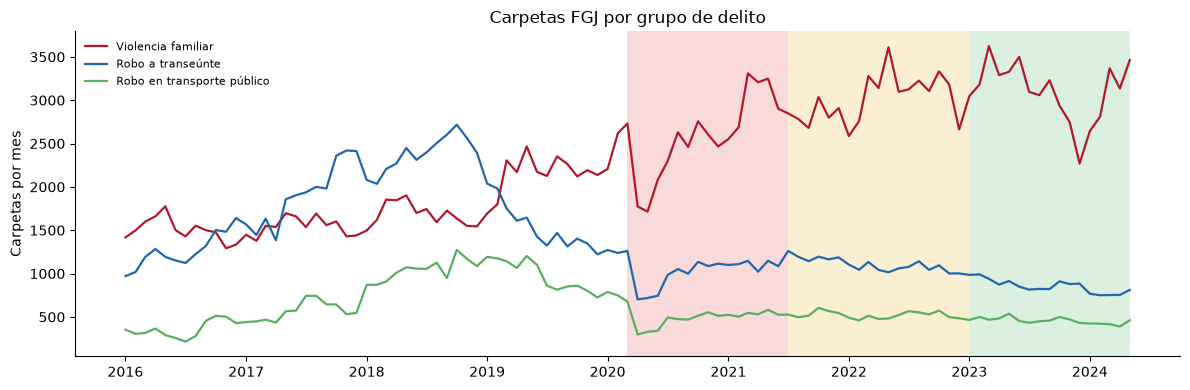

In [23]:
PERIODOS_COLOR = [("2020-03-01", "2021-06-30", "#f4b6b6"), ("2021-07-01", "2022-12-31", "#f9e0a8"), ("2023-01-01", "2026-07-31", "#b9e0c3")]

def sombrear(ax, fin):
    for a, b, c in PERIODOS_COLOR:
        ax.axvspan(pd.Timestamp(a), min(pd.Timestamp(b), fin), color=c, alpha=.5, lw=0)

serie = (fgj_mes[~fgj_mes.mes_incompleto]
         .pivot_table(index="mes", columns="grupo_delito", values="carpetas", aggfunc="sum"))
fig, ax = plt.subplots(figsize=(12, 4))
sombrear(ax, serie.index.max())
for g, c, l in [("violencia_familiar", "#b2182b", "Violencia familiar"),
                ("robo_transeunte", "#2166ac", "Robo a transeúnte"),
                ("robo_transporte_publico", "#5aae61", "Robo en transporte público")]:
    ax.plot(serie.index, serie[g], color=c, lw=1.6, label=l)
ax.set_ylabel("Carpetas por mes"); ax.set_title("Carpetas FGJ por grupo de delito")
ax.legend(frameon=False, fontsize=8, loc="upper left"); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

**Lectura:** la violencia familiar bajó en abril de 2020 (el confinamiento dificultó denunciar) y luego subió con fuerza. El robo a transeúnte cayó y no se ha recuperado, aunque **ya venía bajando desde finales de 2018**, así que no toda la caída se debe a la pandemia.

### 2. Afluencia del Metrobús

**Decisiones de limpieza:**
- En 2023 las líneas venían como `linea N` y en los demás años como `Línea N`: se unificaron (14 → 7 líneas).
- Los vacíos **antes de que se inaugurara cada línea** no son datos faltantes (la línea no existía): se marcan con `linea_operando = False`.
- Los días atípicos se compararon con la mediana móvil de 29 días. Los que corresponden a eventos reales (sismo 19-S, elecciones, festivos, domingos) **se conservan**; solo se anularon 2 errores evidentes.
- 57 valores con decimales (Línea 4, ene–feb 2025) parecen estimaciones del Metrobús: se redondean y se marcan.

#### Limpieza paso a paso
Las celdas siguientes hacen **a la vista** lo mismo que `src/clean/metrobus.py`. Cada paso se anota en `pasos_mb`.

**Paso 0 — Lectura.** Una fila por día y línea, desde julio de 2005.

In [24]:
mb = pd.read_csv(RAW / "metrobus" / "afluencia_diaria_del_metrobus_simple.csv", parse_dates=["fecha"])
pasos_mb = [("Registros leídos (fecha × línea)", f"{len(mb):,}")]
print(mb.shape, "· vacíos en afluencia:", mb.afluencia.isna().sum())
print("Nombres de línea:", sorted(mb.linea.unique()))

(53732, 5) · vacíos en afluencia: 17227
Nombres de línea: ['Línea 1', 'Línea 2', 'Línea 3', 'Línea 4', 'Línea 5', 'Línea 6', 'Línea 7', 'linea 1', 'linea 2', 'linea 3', 'linea 4', 'linea 5', 'linea 6', 'linea 7']


**Paso 1 — Nombres de línea.** En 2023 las líneas vienen como `linea N` y en los demás años como `Línea N`, así que cada línea aparece partida en dos. Se quitan los espacios y se unifica a `Línea N`.

In [25]:
lineas_antes = mb.linea.nunique()
mb["linea"] = mb["linea"].str.strip().str.replace(r"^[Ll][ií]nea", "Línea", regex=True)
pasos_mb.append(("Nombres de línea unificados", f"{lineas_antes} → {mb.linea.nunique()}"))
print(pasos_mb[-1], sorted(mb.linea.unique()))

('Nombres de línea unificados', '14 → 7') ['Línea 1', 'Línea 2', 'Línea 3', 'Línea 4', 'Línea 5', 'Línea 6', 'Línea 7']


**Paso 2 — Vacíos antes de la inauguración y duplicados.** El archivo tiene filas vacías para cada línea desde 2005, aunque varias se inauguraron después. Esos vacíos **no son faltantes**: la línea no existía. Se toma como inicio el primer día con dato de cada línea y se marca `linea_operando`. Luego se revisa si quedan vacíos con la línea ya operando (esos sí serían faltantes) y si hay fechas repetidas por línea.

In [26]:
inicio_linea = mb.dropna(subset=["afluencia"]).groupby("linea").fecha.min()
display(inicio_linea.dt.date.rename("primer día con dato").to_frame())
mb["linea_operando"] = mb.fecha >= mb.linea.map(inicio_linea)
duplicados_mb = mb.duplicated(["fecha", "linea"])
pasos_mb += [("Filas antes de la inauguración (no son faltantes)", f"{(~mb.linea_operando).sum():,}"),
             ("Vacíos con la línea operando", f"{(mb.linea_operando & mb.afluencia.isna()).sum():,}"),
             ("Duplicados fecha × línea", f"{duplicados_mb.sum():,}")]
mb = mb[~duplicados_mb]
pd.DataFrame(pasos_mb[-3:], columns=["paso", "resultado"])

,primer día con dato
linea,
Línea 1,2005-07-26
Línea 2,2008-12-17
Línea 3,2011-02-09
Línea 4,2012-04-02
Línea 5,2013-11-06
Línea 6,2016-01-23
Línea 7,2018-05-02


,paso,resultado
0,Filas antes de la inauguración (no son faltantes),"17,227"
1,Vacíos con la línea operando,0
2,Duplicados fecha × línea,0


**Paso 3 — Valores atípicos.** La afluencia de cada día se divide entre la **mediana móvil de 29 días** de la misma línea. Se revisan los días que están más de 2.5 veces arriba de lo normal o por debajo del 20 %.

In [27]:
mb = mb.sort_values(["linea", "fecha"])
mediana_mb = mb.groupby("linea").afluencia.transform(lambda x: x.rolling(29, center=True, min_periods=10).median())
mb["ratio_mediana"] = (mb.afluencia / mediana_mb).round(3)
mb["atipico"] = (mb.ratio_mediana > 2.5) | (mb.ratio_mediana < 0.2)
pasos_mb.append(("Días atípicos (> 2.5× o < 0.2× la mediana de 29 días)", f"{mb.atipico.sum():,}"))
mb.loc[mb.atipico, ["fecha", "linea", "afluencia", "ratio_mediana"]].sort_values("fecha")

,fecha,linea,afluencia,ratio_mediana
0,2005-07-26,Línea 1,3.032667e+06,12.780
1119,2006-01-01,Línea 1,2.808000e+04,0.170
1217,2006-01-15,Línea 1,4.258600e+04,0.189
1260,2006-01-22,Línea 1,4.366200e+04,0.188
1315,2006-01-29,Línea 1,4.019400e+04,0.170
1837,2006-04-14,Línea 1,3.714400e+04,0.154
18799,2012-12-01,Línea 4,4.930000e+03,0.092
19248,2013-02-03,Línea 4,3.149000e+03,0.063
20080,2013-06-02,Línea 4,8.599000e+03,0.192
20277,2013-06-30,Línea 4,9.954000e+03,0.199


Casi todos son días reales: domingos, 1 de enero, el día posterior al sismo del 19-S, la jornada electoral de 2018, la visita papal de 2016 y los desfiles del 16 de septiembre. Esos se **conservan**. Solo dos son errores evidentes y se **anulan**: quedan vacíos y el motivo se guarda en `error_corregido`.

In [28]:
ERRORES_MB = {
    ("2005-07-26", "Línea 1"): "3.03 M: ~13 veces un día normal; probable acumulado desde la inauguración",
    ("2017-09-20", "Línea 2"): "9 pasajeros el día posterior al sismo 19-S; dato imposible o servicio suspendido",
}
mb["error_corregido"] = ""
for (fecha, linea), motivo in ERRORES_MB.items():
    m = mb.fecha.eq(fecha) & mb.linea.eq(linea)
    print(f"{fecha} {linea}: {mb.loc[m, 'afluencia'].iloc[0]:,.0f} → vacío ({motivo})")
    mb.loc[m, "afluencia"] = pd.NA
    mb.loc[m, "error_corregido"] = motivo
pasos_mb.append(("Errores evidentes anulados", str(len(ERRORES_MB))))

2005-07-26 Línea 1: 3,032,667 → vacío (3.03 M: ~13 veces un día normal; probable acumulado desde la inauguración)
2017-09-20 Línea 2: 9 → vacío (9 pasajeros el día posterior al sismo 19-S; dato imposible o servicio suspendido)


**Paso 4 — Valores con decimales.** La afluencia es un conteo de personas, pero algunos valores traen decimales (Línea 4, enero y febrero de 2025). Probablemente son estimaciones del Metrobús y no conteos: se redondean y se marcan con `valor_estimado`.

In [29]:
mb["valor_estimado"] = mb.afluencia.notna() & (mb.afluencia % 1 != 0)
pasos_mb.append(("Valores con decimales (se redondean y se marcan)", f"{mb.valor_estimado.sum():,}"))
display(mb.loc[mb.valor_estimado, ["fecha", "linea", "afluencia"]].head())
mb["afluencia"] = mb["afluencia"].round().astype("Int64")
print("Valores con decimales:", mb.valor_estimado.sum())

,fecha,linea,afluencia
49696,2025-01-01,Línea 4,32045.00407
49703,2025-01-02,Línea 4,101123.42657
49710,2025-01-03,Línea 4,108617.27820
49717,2025-01-04,Línea 4,104291.42296
49724,2025-01-05,Línea 4,68608.85082


Valores con decimales: 57


**Resultado.** Resumen de los pasos y comprobación contra `metrobus_linea_dia.csv`, que guardó el script. La tabla mensual (`metrobus_mes`) suma solo los días con la línea operando y divide entre los días con dato, para obtener la **afluencia diaria promedio** de cada mes, comparable entre meses de distinta duración.

In [30]:
mb = mb.sort_values(["fecha", "linea"]).reset_index(drop=True)
display(pd.DataFrame(pasos_mb, columns=["paso", "resultado"]))
del_script = pd.read_csv(INTERIM / "metrobus_linea_dia.csv", parse_dates=["fecha"])
print("¿Igual al CSV del script?",
      len(del_script) == len(mb) and del_script.afluencia.sum() == mb.afluencia.sum()
      and del_script.valor_estimado.sum() == mb.valor_estimado.sum())

,paso,resultado
0,Registros leídos (fecha × línea),"53,732"
1,Nombres de línea unificados,14 → 7
2,Filas antes de la inauguración (no son faltantes),"17,227"
3,Vacíos con la línea operando,0
4,Duplicados fecha × línea,0
5,Días atípicos (> 2.5× o < 0.2× la mediana de 2...,30
6,Errores evidentes anulados,2
7,Valores con decimales (se redondean y se marcan),57


¿Igual al CSV del script? True


#### Reporte del script

In [31]:
display(Markdown((DOCS / "limpieza_metrobus.md").read_text(encoding="utf-8")))

# Limpieza de afluencia del Metrobús

Generado por `src/clean/metrobus.py`.

## Pasos

| Paso | Resultado |
|---|---|
| Registros leídos (fecha × línea) | 53,732 |
| Nombres de línea distintos → unificados | 14 → 7 |
| Filas antes de la inauguración de su línea (no son faltantes) | 17,227 |
| Faltantes con la línea operando | 0 |
| Duplicados fecha × línea | 0 |
| Días atípicos (> 2.5× o < 0.2× la mediana de 29 días) | 30 (se conservan salvo errores evidentes) |
| Errores evidentes anulados | 2 |
| Valores con decimales (probables estimaciones; se redondean y marcan) | 57 |

## Errores anulados

| Fecha | Línea | Motivo |
|---|---|---|
| 2005-07-26 | Línea 1 | 3.03 M: ~13 veces un día normal; probable acumulado desde la inauguración |
| 2017-09-20 | Línea 2 | 9 pasajeros el día posterior al sismo 19-S; dato imposible o servicio suspendido |

## Días atípicos conservados (eventos reales)

| Fecha | Línea | Afluencia | × mediana |
|---|---|---:|---:|
| 2006-01-01 | Línea 1 | 28080 | 0.17 |
| 2006-01-15 | Línea 1 | 42586 | 0.189 |
| 2006-01-22 | Línea 1 | 43662 | 0.188 |
| 2006-01-29 | Línea 1 | 40194 | 0.17 |
| 2006-04-14 | Línea 1 | 37144 | 0.154 |
| 2012-12-01 | Línea 4 | 4930 | 0.092 |
| 2013-02-03 | Línea 4 | 3149 | 0.063 |
| 2013-06-02 | Línea 4 | 8599 | 0.192 |
| 2013-06-30 | Línea 4 | 9954 | 0.199 |
| 2013-07-07 | Línea 4 | 8266 | 0.188 |
| 2013-07-14 | Línea 4 | 5798 | 0.152 |
| 2013-07-21 | Línea 4 | 5446 | 0.151 |
| 2013-07-28 | Línea 4 | 5381 | 0.149 |
| 2013-08-04 | Línea 4 | 4944 | 0.134 |
| 2013-09-01 | Línea 4 | 2865 | 0.099 |
| 2013-09-08 | Línea 4 | 2748 | 0.106 |
| 2013-09-15 | Línea 4 | 6102 | 0.186 |
| 2016-02-12 | Línea 4 | 9395 | 0.164 |
| 2016-02-13 | Línea 4 | 6385 | 0.112 |
| 2017-09-20 | Línea 6 | 22550 | 0.11 |
| 2018-07-01 | Línea 7 | 14427 | 0.142 |
| 2019-09-16 | Línea 4 | 10854 | 0.15 |
| 2020-09-16 | Línea 4 | 6238 | 0.148 |
| 2020-12-25 | Línea 4 | 7544 | 0.191 |
| 2021-01-01 | Línea 4 | 7756 | 0.197 |
| 2023-12-31 | Línea 7 | 25208 | 0.198 |
| 2024-10-01 | Línea 4 | 12394 | 0.124 |
| 2026-01-01 | Línea 4 | 12697 | 0.155 |

## Afluencia diaria promedio por año

| Año | Viajes/día | Índice 2019=100 |
|---|---:|---:|
| 2005 | 194,766 | 16.0 |
| 2006 | 203,388 | 16.7 |
| 2007 | 212,749 | 17.5 |
| 2008 | 245,220 | 20.1 |
| 2009 | 348,482 | 28.6 |
| 2010 | 375,214 | 30.8 |
| 2011 | 512,607 | 42.1 |
| 2012 | 601,831 | 49.4 |
| 2013 | 630,223 | 51.8 |
| 2014 | 710,356 | 58.3 |
| 2015 | 757,588 | 62.2 |
| 2016 | 957,497 | 78.6 |
| 2017 | 1,009,578 | 82.9 |
| 2018 | 1,128,730 | 92.7 |
| 2019 | 1,217,528 | 100.0 |
| 2020 | 659,216 | 54.1 |
| 2021 | 846,008 | 69.5 |
| 2022 | 1,199,583 | 98.5 |
| 2023 | 1,374,622 | 112.9 |
| 2024 | 1,447,743 | 118.9 |
| 2025 | 1,397,520 | 114.8 |
| 2026 | 1,370,420 | 112.6 |

Nota: la red creció (Línea 6 en 2016, Línea 7 en 2018 y ampliaciones posteriores), así que
parte del aumento posterior a 2022 refleja más cobertura y no solo más demanda.


In [32]:
mb_dia = pd.read_csv(INTERIM / "metrobus_linea_dia.csv", parse_dates=["fecha"])
print(f"{len(mb_dia):,} filas (fecha × línea) · líneas: {sorted(mb_dia.linea.unique())}")
mb_dia.head()

53,732 filas (fecha × línea) · líneas: ['Línea 1', 'Línea 2', 'Línea 3', 'Línea 4', 'Línea 5', 'Línea 6', 'Línea 7']


,fecha,linea,afluencia,linea_operando,atipico,ratio_mediana,valor_estimado,error_corregido
0,2005-07-26,Línea 1,NaN,True,True,12.78,False,3.03 M: ~13 veces un día normal; probable acum...
1,2005-07-26,Línea 2,NaN,False,False,NaN,False,NaN
2,2005-07-26,Línea 3,NaN,False,False,NaN,False,NaN
3,2005-07-26,Línea 4,NaN,False,False,NaN,False,NaN
4,2005-07-26,Línea 5,NaN,False,False,NaN,False,NaN


In [33]:
# Faltantes reales: días en que la línea ya operaba pero no hay dato
operando = mb_dia[mb_dia.linea_operando]
print("Vacíos con la línea operando:", operando.afluencia.isna().sum(), "(son los 2 errores anulados)")
print("Días faltantes en el calendario:",
      len(pd.date_range(mb_dia.fecha.min(), mb_dia.fecha.max()).difference(mb_dia.fecha.unique())))
mb_dia[mb_dia.error_corregido.fillna("") != ""]

Vacíos con la línea operando: 2 (son los 2 errores anulados)
Días faltantes en el calendario: 0


,fecha,linea,afluencia,linea_operando,atipico,ratio_mediana,valor_estimado,error_corregido
0,2005-07-26,Línea 1,NaN,True,True,12.78,False,3.03 M: ~13 veces un día normal; probable acum...
31074,2017-09-20,Línea 2,NaN,True,True,0.00,False,9 pasajeros el día posterior al sismo 19-S; da...


In [34]:
mb_mes = pd.read_csv(INTERIM / "metrobus_mes.csv", parse_dates=["mes"])
mb_mes.tail()

,mes,afluencia_total,lineas_operando,dias_con_dato,afluencia_diaria_promedio,linea_1,linea_2,linea_3,linea_4,linea_5,linea_6,linea_7
248,2026-03-01,44002655,7,31,1419440.0,13430056,5895678.0,5213618.0,2612766.0,7608767.0,5678821.0,3562949.0
249,2026-04-01,42149475,7,30,1404982.0,12905050,5625436.0,5147879.0,2640207.0,7152323.0,5175651.0,3502929.0
250,2026-05-01,43122913,7,31,1391062.0,12898988,5956492.0,5271974.0,2570282.0,7491785.0,5530040.0,3403352.0
251,2026-06-01,39751764,7,30,1325059.0,12372400,5622688.0,4906584.0,1102181.0,7262320.0,5574803.0,2910788.0
252,2026-07-01,40771965,7,31,1315225.0,12361362,5325716.0,5081193.0,2559613.0,7000955.0,5238929.0,3204197.0


#### Metro frente a Metrobús (índice 2019 = 100)

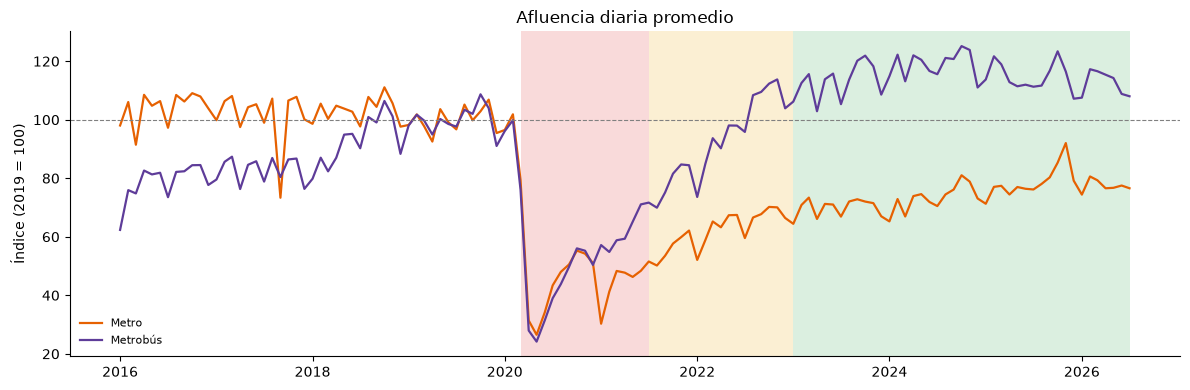

,Metro,Metrobús
2016,104.0,78.6
2017,101.3,82.9
2018,103.3,92.7
2019,100.0,100.0
2020,56.0,54.1
2021,49.8,69.5
2022,64.6,98.5
2023,69.9,112.9
2024,73.3,118.9
2025,78.7,114.8


In [35]:
metro = pd.read_csv(RAW / "metro" / "afluencia_metro_simple.csv", parse_dates=["fecha"])
metro_mes = metro.set_index("fecha").afluencia.resample("MS").sum()
metro_mes = metro_mes / metro_mes.index.days_in_month          # promedio diario del mes
mb = mb_mes.set_index("mes").afluencia_diaria_promedio

idx_metro = (metro_mes / metro_mes["2019"].mean() * 100)["2016":]
idx_mb = (mb / mb["2019"].mean() * 100)["2016":]

fig, ax = plt.subplots(figsize=(12, 4))
sombrear(ax, idx_mb.index.max())
ax.plot(idx_metro.index, idx_metro, color="#e66101", lw=1.6, label="Metro")
ax.plot(idx_mb.index, idx_mb, color="#5e3c99", lw=1.6, label="Metrobús")
ax.axhline(100, color="grey", lw=.8, ls="--")
ax.set_ylabel("Índice (2019 = 100)"); ax.set_title("Afluencia diaria promedio")
ax.legend(frameon=False, fontsize=8, loc="lower left"); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

pd.DataFrame({"Metro": idx_metro.groupby(idx_metro.index.year).mean(),
              "Metrobús": idx_mb.groupby(idx_mb.index.year).mean()}).round(1)

**Lectura:** los dos sistemas cayeron ~75 % en mayo de 2020, pero el Metrobús ya supera su nivel de 2019 mientras el Metro sigue en 73–79. Posibles causas: la ampliación de la red del Metrobús y el traslado de usuarios por los cierres de las Líneas 1 y 12 del Metro.

---
## Puestos de trabajo asegurados (IMSS)

**Objetivo:** una tabla con el empleo formal de la CDMX por **mes y subdelegación del IMSS** (128 meses × 10 subdelegaciones = 1,280 filas), con los puestos por sexo, por tipo de contrato y por rango salarial, y el salario promedio.

**Fuente:** 128 archivos mensuales (`asg_cdmx_AAAA_MM.csv.gz`, enero de 2016 a agosto de 2026), ya filtrados a la CDMX al descargarlos. Cada uno tiene unas 500 mil filas: una por cada combinación de oficina, sector, sexo, edad, rango salarial, etc.

**Pasos:**
1. Leer cada mes con su codificación y solo las columnas necesarias.
2. Revisar los vacíos del rango salarial.
3. Agrupar los rangos de UMA en 3 grupos.
4. Poner nombre a las subdelegaciones con el diccionario oficial.
5. Resumir cada mes por subdelegación.
6. Procesar los 128 meses y unirlos.
7. Validar y guardar.

⚠️ El IMSS **no publica la CDMX por alcaldía** (`cve_municipio` viene vacío en todos los meses). Las delegaciones (39 Norte y 40 Sur) y las subdelegaciones son oficinas del IMSS, no alcaldías.

### Paso 1 — Archivos disponibles
Se listan los archivos mensuales. El primero (enero de 2016) no está comprimido.

In [36]:
from pathlib import Path
import gzip
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_IMSS = RAIZ / "data" / "raw" / "imss"
INTERIM = RAIZ / "data" / "interim"

archivos = sorted(RAW_IMSS.glob("asg_cdmx_*.csv*"))
for ruta in archivos:
    print(ruta)

/home/mrangello/Música/Metro/data/raw/imss/asg_cdmx_2016_01.csv
/home/mrangello/Música/Metro/data/raw/imss/asg_cdmx_2016_02.csv.gz
/home/mrangello/Música/Metro/data/raw/imss/asg_cdmx_2016_03.csv.gz
/home/mrangello/Música/Metro/data/raw/imss/asg_cdmx_2016_04.csv.gz
/home/mrangello/Música/Metro/data/raw/imss/asg_cdmx_2016_05.csv.gz
/home/mrangello/Música/Metro/data/raw/imss/asg_cdmx_2016_06.csv.gz
/home/mrangello/Música/Metro/data/raw/imss/asg_cdmx_2016_07.csv.gz
/home/mrangello/Música/Metro/data/raw/imss/asg_cdmx_2016_08.csv.gz
/home/mrangello/Música/Metro/data/raw/imss/asg_cdmx_2016_09.csv.gz
/home/mrangello/Música/Metro/data/raw/imss/asg_cdmx_2016_10.csv.gz
/home/mrangello/Música/Metro/data/raw/imss/asg_cdmx_2016_11.csv.gz
/home/mrangello/Música/Metro/data/raw/imss/asg_cdmx_2016_12.csv.gz
/home/mrangello/Música/Metro/data/raw/imss/asg_cdmx_2017_01.csv.gz
/home/mrangello/Música/Metro/data/raw/imss/asg_cdmx_2017_02.csv.gz
/home/mrangello/Música/Metro/data/raw/imss/asg_cdmx_2017_03.csv.g

### Paso 1 (cont.) — Leer un mes
Esta celda resuelve tres problemas de la fuente:
- **La codificación cambia entre años** (Latin-1 en unos, UTF-8 en otros): se intenta decodificar una muestra en UTF-8 y, si falla, se usa Latin-1.
- **Las columnas cambian:** `rango_uma` no existe antes de febrero de 2017, y en algunos meses un nombre de columna viene mal codificado. Se leen solo las columnas de `COLUMNAS` que traiga el archivo; si falta `rango_uma`, se crea vacía.
- **Texto a número:** los conteos se convierten a número; lo que no es numérico queda en 0.

La fecha se toma del nombre del archivo. Se prueba con diciembre de 2019.

In [37]:
  COLUMNAS= [
      "cve_delegacion", "cve_subdelegacion",   # dónde (oficina del IMSS)
      "sexo",                                   # para hombres / mujeres
      "rango_salarial", "rango_uma",            # rangos de salario
      "asegurados", "no_trabajadores",          # personas afiliadas (con y sin empleo)
      "ta",                                     # PUESTOS DE TRABAJO = empleo formal
      "tpu", "teu",                             # permanentes / eventuales
      "ta_sal", "masa_sal_ta",                  # para calcular el salario promedio
  ]
  def abrir(ruta):
      return gzip.open(ruta, "rb") if ruta.suffix == ".gz" else open(ruta, "rb")

  def detectar_codificacion(ruta):
      with abrir(ruta) as f:
          muestra = f.read(200_000)
      try:
          muestra.decode("utf-8")
          return "utf-8-sig"
      except UnicodeDecodeError:
          return "latin-1"

  def leer_mes(ruta):
      cod = detectar_codificacion(ruta)
      with abrir(ruta) as f:
          encabezado = f.readline().decode(cod).strip().split("|")
      usar = [c for c in COLUMNAS if c in encabezado]   # rango_uma no existe en 2016
      df = pd.read_csv(ruta, sep="|", encoding=cod, usecols=usar, dtype=str)
      for c in ["asegurados", "no_trabajadores", "ta", "tpu", "teu", "ta_sal", "masa_sal_ta"]:
          df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)
      if "rango_uma" not in df:
          df["rango_uma"] = pd.NA
      df["fecha"] = pd.Timestamp(ruta.name[9:13] + "-" + ruta.name[14:16] + "-01")
      return df, encabezado

  ejemplo, encabezado = leer_mes(RAW_IMSS / "asg_cdmx_2019_12.csv.gz")

### Paso 2 — Vacíos en el rango salarial
El rango salarial viene vacío en algunas filas. Antes de decidir qué hacer se revisa **de quién** son esas filas: si son asegurados sin empleo, que no tienen salario, no es un faltante que deba imputarse.

In [38]:
  vacio = ejemplo["rango_uma"].isna()
  print(f"Filas con rango vacío: {vacio.sum():}")
  print(f"  asegurados SIN empleo en ellas: {ejemplo.loc[vacio, 'no_trabajadores'].sum():,.0f}")
  print(f"  puestos de trabajo en ellas:    {ejemplo.loc[vacio, 'ta'].sum():,.0f} "
        f"de {ejemplo['ta'].sum():,.0f} ({ejemplo.loc[vacio, 'ta'].sum() / ejemplo['ta'].sum():.2%})")

Filas con rango vacío: 736
  asegurados SIN empleo en ellas: 2,019,293
  puestos de trabajo en ellas:    3,944 de 3,470,048 (0.11%)


Casi todas las filas vacías son de **asegurados sin empleo**, que no tienen salario, así que no se imputa nada. Los puestos de trabajo sin rango son muy pocos (0.11 % en este mes) y van a una categoría `sin_dato`.

### Paso 3 — Agrupar los rangos salariales
El IMSS publica 25 rangos (`W1` … `W25`) en múltiplos de la UMA. Se agrupan en tres: hasta 2 UMA, de 2 a 5 UMA y más de 5 UMA. Antes de febrero de 2017 no existe `rango_uma`; se usa `rango_salarial` (en salarios mínimos), que en 2016 es equivalente porque la UMA valía lo mismo que el salario mínimo ($73.04). Enero de 2017 queda aproximado.

In [39]:
  FECHA_INICIO_UMA = pd.Timestamp("2017-02-01")   # antes, rango_uma no existe

  def grupo_salarial(codigo):
      """W1..W25 → 3 grupos. Vacío con empleo → 'sin_dato'."""
      if pd.isna(codigo):
          return "sin_dato"
      n = int(str(codigo).strip().upper().lstrip("W"))
      if n <= 2:
          return "hasta_2"      # W1–W2: hasta 2 UMA
      if n <= 5:
          return "de_2_a_5"     # W3–W5: de 2 a 5 UMA
      return "mas_de_5"         # W6+: más de 5 UMA

  {w: grupo_salarial(w) for w in ["W1", "W2", "W3", "W5", "W6", "W25", None]}

{'W1': 'hasta_2',
 'W2': 'hasta_2',
 'W3': 'de_2_a_5',
 'W5': 'de_2_a_5',
 'W6': 'mas_de_5',
 'W25': 'mas_de_5',
 None: 'sin_dato'}

### Paso 4 — Nombres de las subdelegaciones
Las claves de oficina se cruzan con la hoja *delegación-subdelegación* del diccionario oficial del IMSS. Solo interesan las delegaciones 39 (CDMX Norte) y 40 (CDMX Sur).

In [40]:
  dic = pd.read_excel(RAW_IMSS / "diccionario_de_datos_imss.xlsx",
                      sheet_name="delegación-subdelegación", header=1)
  dic.columns = ["cve_delegacion", "delegacion", "cve_subdelegacion", "subdelegacion"]
  dic = dic.dropna(subset=["cve_subdelegacion"])
  dic["cve_delegacion"] = dic["cve_delegacion"].astype(int).astype(str)
  dic["cve_subdelegacion"] = dic["cve_subdelegacion"].astype(int).astype(str)

  nombres = dic[dic["cve_delegacion"].isin(["39", "40"])]   # 39 = CDMX Norte, 40 = CDMX Sur
  nombres

,cve_delegacion,delegacion,cve_subdelegacion,subdelegacion
123,39,Ciudad de México Norte,11,Magdalena de las Salinas
124,39,Ciudad de México Norte,16,Polanco
125,39,Ciudad de México Norte,54,Santa MarÍa la Ribera
126,39,Ciudad de México Norte,56,Guerrero
127,39,Ciudad de México Norte,57,Centro
128,40,Ciudad de México Sur,1,San Ángel
129,40,Ciudad de México Sur,6,Del Valle
130,40,Ciudad de México Sur,11,Santa Anita
131,40,Ciudad de México Sur,54,Churubusco
132,40,Ciudad de México Sur,58,Piedad Narvarte


### Paso 5 — Resumir un mes por subdelegación
Las ~500 mil filas del mes se reducen a una fila por subdelegación:
- **Puestos** = `ta` (puestos de trabajo). Se usan en lugar de `asegurados`, que incluye a personas afiliadas sin empleo.
- **Hombres / mujeres / no binario** = puestos por sexo.
- **Rangos de UMA:** solo con las filas que tienen empleo.
- **Salario promedio** = masa salarial ÷ puestos con salario (pesos diarios, nominales).

In [41]:
  def resumir_mes(df):
      df = df.copy()
      # 2016 y enero 2017: no hay rango_uma. En 2016 UMA = salario mínimo ($73.04) → copia exacta.
      # (enero 2017 queda aproximado)
      if df["fecha"].iloc[0] < FECHA_INICIO_UMA:
          df["rango_uma"] = df["rango_salarial"]
      df["grupo_uma"] = df["rango_uma"].map(grupo_salarial)
      df["sexo"] = df["sexo"].map({"1": "hombres", "2": "mujeres", "3": "no_binario"})

      llaves = ["fecha", "cve_delegacion", "cve_subdelegacion"]

      # sumas
      base = df.groupby(llaves)[["asegurados", "ta", "tpu", "teu", "ta_sal", "masa_sal_ta"]].sum()
      # hombres / mujeres = PUESTOS de trabajo por sexo
      por_sexo = df.pivot_table(index=llaves, columns="sexo", values="ta", aggfunc="sum", fill_value=0)
      # rangos: solo filas con empleo (los asegurados sin empleo no tienen salario)
      con_empleo = df[df["ta"] > 0]
      por_rango = con_empleo.pivot_table(index=llaves, columns="grupo_uma", values="ta",
                                         aggfunc="sum", fill_value=0)
      por_rango.columns = ["uma_" + c for c in por_rango.columns]

      r = base.join(por_sexo).join(por_rango).reset_index()
      r["salario_promedio"] = (r["masa_sal_ta"] / r["ta_sal"]).round(2)   # pesos diarios
      return r.rename(columns={"ta": "puestos", "tpu": "permanentes", "teu": "eventuales"})
  resumir_mes(ejemplo)

,fecha,cve_delegacion,cve_subdelegacion,asegurados,puestos,permanentes,eventuales,ta_sal,masa_sal_ta,hombres,mujeres,uma_de_2_a_5,uma_hasta_2,uma_mas_de_5,uma_sin_dato,salario_promedio
0,2019-12-01,39,11,618220,353549,317998,35551,353339,1.491207e+08,207757,145792,118430,123825,111084,210,422.03
1,2019-12-01,39,16,686053,664949,571555,93394,664183,4.279164e+08,390975,273974,196042,160108,308033,766,644.27
2,2019-12-01,39,54,283550,272438,236885,35553,272350,1.294679e+08,159203,113235,103388,78681,90281,88,475.37
3,2019-12-01,39,56,234752,197466,163705,33761,197201,7.687260e+07,119931,77535,67839,70974,58388,265,389.82
4,2019-12-01,39,57,1028209,193066,171319,21747,191685,9.859512e+07,107913,85153,60078,62338,69269,1381,514.36
5,2019-12-01,40,1,917952,419375,368611,50753,419275,1.849938e+08,240578,178797,145668,151334,122273,100,441.22
6,2019-12-01,40,11,229630,196232,176439,19793,196148,6.845498e+07,116617,79615,73405,75916,46827,84,349.00
7,2019-12-01,40,54,527491,329752,287471,42279,329561,1.050201e+08,197338,132414,107692,157910,63959,191,318.67
8,2019-12-01,40,58,616414,566052,492432,73620,565863,2.804871e+08,325298,240754,177533,191307,197023,189,495.68
9,2019-12-01,40,6,347070,277169,234480,42689,276499,1.131118e+08,157369,119800,94276,102255,79968,670,409.09


### Paso 6 — Procesar los 128 meses
Se aplica lo anterior a cada archivo y se unen los resultados. Una columna que no aparece en algún mes (por ejemplo, `no_binario` en los años anteriores a que existiera esa opción) queda en 0, porque ese mes no hubo puestos con ese valor.

In [42]:
  meses = []
  archivos = sorted(RAW_IMSS.glob("asg_cdmx_*.csv*"))
  for i, ruta in enumerate(archivos, 1):
      df, _ = leer_mes(ruta)
      meses.append(resumir_mes(df))
      if i % 12 == 0 or i == len(archivos):
          print(f"  {i}/{len(archivos)} … {ruta.name}")

  imss = pd.concat(meses, ignore_index=True).fillna(0)
  imss = imss.merge(nombres, on=["cve_delegacion", "cve_subdelegacion"], how="left")
  
  columnas = ["fecha", "cve_delegacion", "delegacion", "cve_subdelegacion", "subdelegacion",
              "asegurados", "puestos", "hombres", "mujeres", "no_binario",
              "permanentes", "eventuales",
              "uma_hasta_2", "uma_de_2_a_5", "uma_mas_de_5", "uma_sin_dato",
              "salario_promedio"]
  for c in columnas:          # por si algún mes no tiene, por ejemplo, 'no_binario'
      if c not in imss:       
          imss[c] = 0
  imss = imss[columnas].sort_values(["fecha", "cve_delegacion", "cve_subdelegacion"]).reset_index(drop=True)
  imss.head(12)

  12/128 … asg_cdmx_2016_12.csv.gz


  24/128 … asg_cdmx_2017_12.csv.gz


  36/128 … asg_cdmx_2018_12.csv.gz


  48/128 … asg_cdmx_2019_12.csv.gz


  60/128 … asg_cdmx_2020_12.csv.gz


...

  96/128 … asg_cdmx_2023_12.csv.gz


  108/128 … asg_cdmx_2024_12.csv.gz


  120/128 … asg_cdmx_2025_12.csv.gz


  128/128 … asg_cdmx_2026_08.csv.gz


,fecha,cve_delegacion,delegacion,cve_subdelegacion,subdelegacion,asegurados,puestos,hombres,mujeres,no_binario,permanentes,eventuales,uma_hasta_2,uma_de_2_a_5,uma_mas_de_5,uma_sin_dato,salario_promedio
0,2016-01-01,39,Ciudad de México Norte,11,Magdalena de las Salinas,601613,328058,199404,128654,0.0,287862,40196,114886,113670,99249,253,349.18
1,2016-01-01,39,Ciudad de México Norte,16,Polanco,615145,592340,349173,243167,0.0,520566,71774,165408,168035,258164,733,538.73
2,2016-01-01,39,Ciudad de México Norte,54,Santa MarÍa la Ribera,339600,237477,141331,96146,0.0,206736,30741,67763,87755,81852,107,416.39
3,2016-01-01,39,Ciudad de México Norte,56,Guerrero,235839,191029,114351,76678,0.0,164703,26326,76559,62617,51650,203,317.60
4,2016-01-01,39,Ciudad de México Norte,57,Centro,193175,175655,98841,76814,0.0,155956,19699,56035,47139,71652,829,476.97
5,2016-01-01,40,Ciudad de México Sur,1,San Ángel,693659,321378,189638,131740,0.0,272208,49170,113718,104585,103010,65,406.09
6,2016-01-01,40,Ciudad de México Sur,11,Santa Anita,238865,201630,123110,78520,0.0,182243,19387,77707,75866,47964,93,309.00
7,2016-01-01,40,Ciudad de México Sur,54,Churubusco,615045,287768,175446,112322,0.0,248805,38963,132088,95492,59985,203,282.13
8,2016-01-01,40,Ciudad de México Sur,58,Piedad Narvarte,524702,507237,302939,204298,0.0,431127,76110,155222,163744,188150,121,452.63
9,2016-01-01,40,Ciudad de México Sur,6,Del Valle,336903,296940,177093,119847,0.0,258241,38699,96239,110533,89430,738,361.18


### Paso 7 — Validación
Se comprueba que no falte ningún mes, que todas las subdelegaciones tengan nombre y que hombres + mujeres + no binario, y también la suma de los rangos, den **exactamente** el total de puestos. Diciembre de 2019 debe coincidir con el total calculado directamente del archivo original (3,470,048 puestos).

In [43]:
  print("Filas:", len(imss), "| meses:", imss["fecha"].nunique(),
        "| subdelegaciones:", imss.groupby(["cve_delegacion", "cve_subdelegacion"]).ngroups)

  esperados = pd.date_range(imss["fecha"].min(), imss["fecha"].max(), freq="MS")
  print("Meses faltantes:", list(esperados.difference(imss["fecha"])))
  print("Subdelegaciones sin nombre:", imss["subdelegacion"].isna().sum())

  # hombres + mujeres + no binario debe ser igual a puestos; lo mismo con los rangos
  dif_sexo = (imss["hombres"] + imss["mujeres"] + imss["no_binario"] - imss["puestos"]).abs().max()
  dif_rango = (imss[["uma_hasta_2", "uma_de_2_a_5", "uma_mas_de_5", "uma_sin_dato"]].sum(axis=1)
               - imss["puestos"]).abs().max()
  print("Diferencia máx. sexo vs puestos:", dif_sexo, "| rangos vs puestos:", dif_rango)

  # total de la CDMX en meses clave
  cdmx = imss.groupby("fecha")[["puestos", "hombres", "mujeres", "asegurados"]].sum()
  cdmx.loc[["2019-12-01", "2020-06-01", "2024-12-01", "2026-08-01"]]

Filas: 1280 | meses: 128 | subdelegaciones: 10
Meses faltantes: []
Subdelegaciones sin nombre: 0
Diferencia máx. sexo vs puestos: 0.0 | rangos vs puestos: 0


,puestos,hombres,mujeres,asegurados
fecha,,,,
2019-12-01,3470048,2022979,1447069,5489341
2020-06-01,3263299,1904662,1358637,5054592
2024-12-01,3479354,1960731,1518611,4743240
2026-08-01,3689815,2104533,1585251,5160496


### Guardado

In [44]:
  salida = INTERIM / "imss_subdelegacion_mes.csv"
  imss.to_csv(salida, index=False, encoding="utf-8-sig",date_format="%d/%m/%Y")
  print(f"Guardado: {salida}  ({len(imss):,} filas)")

Guardado: /home/mrangello/Música/Metro/data/interim/imss_subdelegacion_mes.csv  (1,280 filas)


### Gráficas para ver la distribución

In [45]:
  from pathlib import Path
  import pandas as pd
  import matplotlib.pyplot as plt
  import matplotlib.dates as mdates

  RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
  ENTRADA = RAIZ / "data" / "interim" / "imss_subdelegacion_mes.csv"
  FIGURAS = RAIZ / "informe" / "figuras"

  TOP_N = 5          # cuántas subdelegaciones graficar (hay 10)
  GUARDAR = True     # False = solo mostrar, sin guardar PNG

  PERIODOS = [("2020-03-01", "2021-06-30", "#f4b6b6", "Choque"),
              ("2021-07-01", "2022-12-31", "#f9e0a8", "Transición"),
              ("2023-01-01", "2026-12-31", "#b9e0c3", "Post-pandemia")]
  RANGOS = {"uma_hasta_2": ("Hasta 2 UMA", "#d73027"),
            "uma_de_2_a_5": ("De 2 a 5 UMA", "#fdae61"),
            "uma_mas_de_5": ("Más de 5 UMA", "#4575b4"),
            "uma_sin_dato": ("Sin dato", "#bdbdbd")}

  imss = pd.read_csv(ENTRADA, dtype={"cve_delegacion": str, "cve_subdelegacion": str})
  imss["fecha"] = pd.to_datetime(imss["fecha"], format="%d/%m/%Y")     # guardaste la fecha como dd/mm/aaaa
  imss["delegacion"] = imss["delegacion"].str.strip()                   # quita el espacio del final
  zona = imss["delegacion"].str.replace("Ciudad de México ", "", regex=False)
  imss["nombre"] = imss["subdelegacion"].str.strip() + " (" + zona + ")"
  imss = imss.sort_values("fecha")

  print(f"{len(imss):,} filas · {imss.fecha.min().date()} → {imss.fecha.max().date()}")

1,280 filas · 2016-01-01 → 2026-08-01


In [46]:
  def sombrear(ax, fin):
      for inicio, final, color, _ in PERIODOS:
          ax.axvspan(pd.Timestamp(inicio), min(pd.Timestamp(final), fin), color=color, alpha=.45, lw=0)

  def estilo(ax, titulo, ylabel):
      ax.set_title(titulo, loc="left", fontsize=12)
      ax.set_ylabel(ylabel)
      ax.xaxis.set_major_locator(mdates.YearLocator())
      ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
      ax.spines[["top", "right"]].set_visible(False)
      ax.grid(axis="y", alpha=.3)

Top: ['Polanco (Norte)', 'Piedad Narvarte (Sur)', 'San Ángel (Sur)', 'Magdalena de las Salinas (Norte)', 'Churubusco (Sur)']


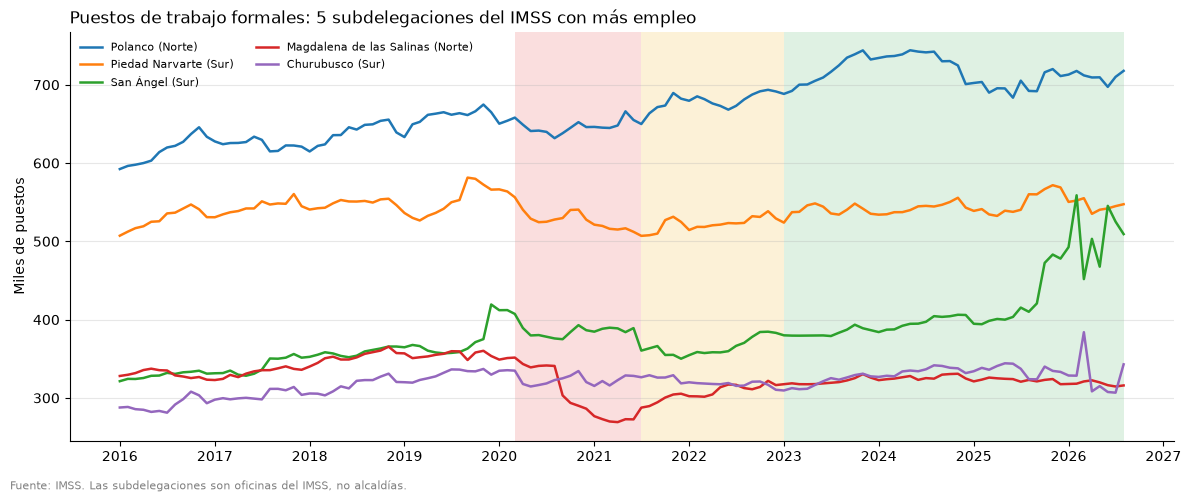

In [47]:
# las TOP_N con más puestos en 2019 (antes de la pandemia)
top = (imss[imss.fecha.dt.year == 2019].groupby("nombre")["puestos"].mean()
       .sort_values(ascending=False).head(TOP_N).index.tolist())
print("Top:", top)

fig, ax = plt.subplots(figsize=(12, 5))
sombrear(ax, imss.fecha.max())
for nombre in top:
    s = imss[imss.nombre == nombre].set_index("fecha")["puestos"] / 1_000
    ax.plot(s.index, s, lw=1.8, label=nombre)
estilo(ax, f"Puestos de trabajo formales: {TOP_N} subdelegaciones del IMSS con más empleo", "Miles de puestos")
ax.legend(frameon=False, fontsize=8, loc="upper left", ncols=2)
fig.text(0.01, 0.01, "Fuente: IMSS. Las subdelegaciones son oficinas del IMSS, no alcaldías.", fontsize=8, color="grey")
fig.tight_layout(rect=(0, 0.03, 1, 1))
if GUARDAR:
    fig.savefig(FIGURAS / "imss_top_subdelegaciones.png", dpi=160)
plt.show()

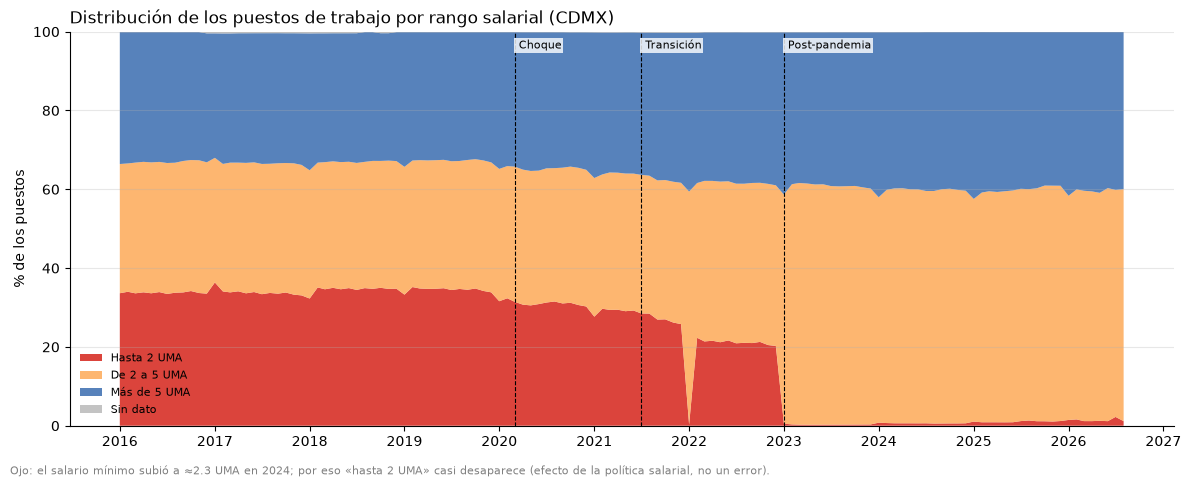

In [48]:
  cdmx = imss.groupby("fecha")[list(RANGOS)].sum()
  porcentaje = cdmx.div(cdmx.sum(axis=1), axis=0) * 100

  fig, ax = plt.subplots(figsize=(12, 5))
  ax.stackplot(porcentaje.index, [porcentaje[c] for c in RANGOS],
               labels=[etq for etq, _ in RANGOS.values()],
               colors=[col for _, col in RANGOS.values()], alpha=.9)
  for inicio, _, _, etiqueta in PERIODOS:
      ax.axvline(pd.Timestamp(inicio), color="black", lw=.8, ls="--")
      ax.text(pd.Timestamp(inicio), 98, " " + etiqueta, fontsize=8, va="top",
            bbox=dict(facecolor="white", alpha=.8, lw=0, pad=1))
  estilo(ax, "Distribución de los puestos de trabajo por rango salarial (CDMX)", "% de los puestos")
  ax.set_ylim(0, 100)
  ax.legend(frameon=False, fontsize=8, loc="lower left")
  fig.text(0.01, 0.01, "Ojo: el salario mínimo subió a ≈2.3 UMA en 2024; por eso «hasta 2 UMA» casi "
           "desaparece (efecto de la política salarial, no un error).", fontsize=8, color="grey")
  fig.tight_layout(rect=(0, 0.03, 1, 0.97))
  if GUARDAR:
      fig.savefig(FIGURAS / "imss_rangos_uma.png", dpi=160)
  plt.show()

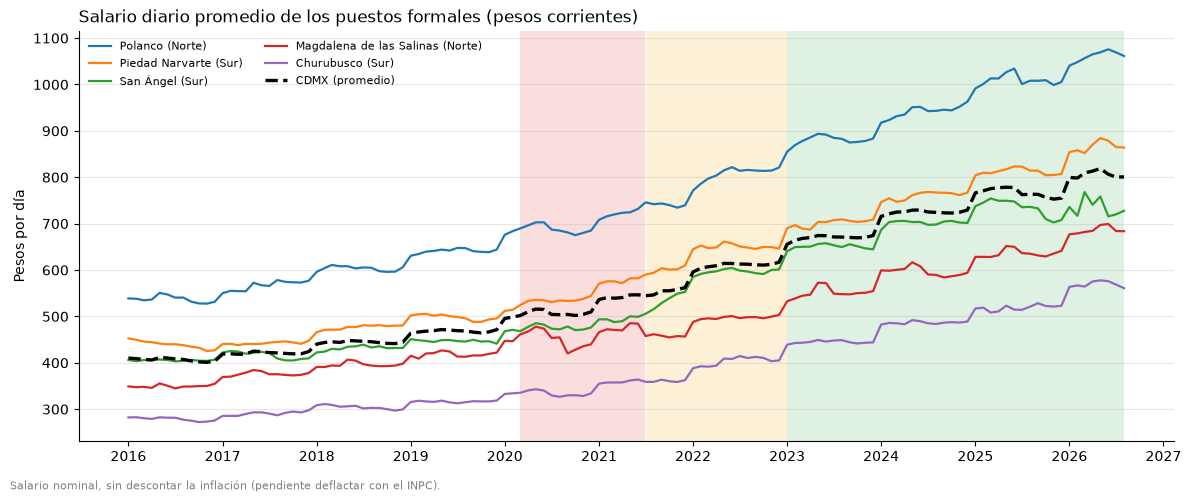

In [49]:
fig, ax = plt.subplots(figsize=(12, 5))
sombrear(ax, imss.fecha.max())
for nombre in top:
    s = imss[imss.nombre == nombre].set_index("fecha")["salario_promedio"]
    ax.plot(s.index, s, lw=1.6, label=nombre)

# promedio de toda la CDMX, ponderado por el número de puestos
pond = (imss.salario_promedio * imss.puestos).groupby(imss.fecha).sum() / imss.groupby("fecha").puestos.sum()
ax.plot(pond.index, pond, color="black", lw=2.4, ls="--", label="CDMX (promedio)")

estilo(ax, "Salario diario promedio de los puestos formales (pesos corrientes)", "Pesos por día")
ax.legend(frameon=False, fontsize=8, loc="upper left", ncols=2)
fig.text(0.01, 0.01, "Salario nominal, sin descontar la inflación (pendiente deflactar con el INPC).",
         fontsize=8, color="grey")
fig.tight_layout(rect=(0, 0.03, 1, 1))
if GUARDAR:
    fig.savefig(FIGURAS / "imss_salario_subdelegaciones.png", dpi=160)
plt.show()

---
## Ocupación hotelera

**Revisión previa:** dentro de su periodo (oct-2018 → jul-2024) no le falta ningún dato: sin vacíos, sin meses faltantes y sin valores fuera de 0–100 %. Los valores de abril–junio de 2020 (1.6–3.4 %) **son reales** (confinamiento) y se conservan.

**Limpieza que se aplica:**
1. **Redondear a 2 decimales**: desde 2020-02 algunos valores traen muchos decimales y otros solo dos (la fuente cambió su forma de calcularlo).
2. **Fecha al primer día del mes**: viene como fin de mes (`2019-01-31`); el IMSS, la FGJ y el Metrobús usan el primer día (`2019-01-01`), y así se podrán unir.
3. **Nombre de columna claro**: `ciudad_de_mexico` → `ocupacion_pct`.

*Pendiente (paso de completar): backcasting 2016 → 2018-09 con el empleo IMSS del sector de hoteles y restaurantes.*

In [50]:
from pathlib import Path
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = RAIZ / "data" / "raw"
INTERIM = RAIZ / "data" / "interim"

hoteles_raw = pd.read_csv(RAW / "hoteles" / "porcentaje_de_ocupacion_promedio_mensual.csv")
print(hoteles_raw.shape, hoteles_raw.dtypes.to_dict())
hoteles_raw.head()

(70, 2) {'fecha': <StringDtype(na_value=nan)>, 'ciudad_de_mexico': dtype('float64')}


,fecha,ciudad_de_mexico
0,2018-10-31,73.17
1,2018-11-30,75.58
2,2018-12-31,65.45
3,2019-01-31,53.13
4,2019-02-28,69.30


### Revisión de faltantes (los tres tipos)
Antes de limpiar se buscan los tres tipos de faltantes: **celdas vacías**, **meses que no aparecen** (comparando contra el calendario completo de fines de mes) y **faltantes disfrazados** (ceros, negativos o porcentajes mayores a 100). También se buscan fechas duplicadas.

In [51]:
h = hoteles_raw.copy()
h["fecha"] = pd.to_datetime(h["fecha"])

print("1) Celdas vacías:", h.isna().sum().to_dict())
todas = pd.date_range(h["fecha"].min(), h["fecha"].max(), freq="ME")      # todos los fines de mes
print("2) Meses faltantes:", list(todas.difference(h["fecha"])))
v = h["ciudad_de_mexico"]
print("3) Disfrazados → ceros:", (v == 0).sum(), "| negativos:", (v < 0).sum(), "| mayores a 100:", (v > 100).sum())
print("   Duplicados de fecha:", h["fecha"].duplicated().sum())

1) Celdas vacías: {'fecha': 0, 'ciudad_de_mexico': 0}
2) Meses faltantes: []
3) Disfrazados → ceros: 0 | negativos: 0 | mayores a 100: 0
   Duplicados de fecha: 0


### Paso 1 — Redondear a 2 decimales
Antes de redondear, se cuenta cuántos valores traían más de 2 decimales (para documentarlo).

In [52]:
decimales = h["ciudad_de_mexico"].astype(str).str.split(".").str[1].str.len()
muchos = h[decimales > 2]
print(f"Valores con más de 2 decimales: {len(muchos)} de {len(h)} "
      f"(desde {muchos['fecha'].min():%Y-%m} hasta {muchos['fecha'].max():%Y-%m})")

h["ciudad_de_mexico"] = h["ciudad_de_mexico"].round(2)
h.loc[muchos.index].head()

Valores con más de 2 decimales: 47 de 70 (desde 2020-02 hasta 2024-04)


,fecha,ciudad_de_mexico
16,2020-02-29,69.87
17,2020-03-31,39.02
18,2020-04-30,2.76
19,2020-05-31,1.55
20,2020-06-30,3.36


### Paso 2 — Fecha al primer día del mes

In [53]:
antes = h["fecha"].copy()
h["fecha"] = h["fecha"].dt.to_period("M").dt.to_timestamp()      # 2019-01-31 → 2019-01-01
pd.DataFrame({"antes": antes, "después": h["fecha"]}).head()

,antes,después
0,2018-10-31,2018-10-01
1,2018-11-30,2018-11-01
2,2018-12-31,2018-12-01
3,2019-01-31,2019-01-01
4,2019-02-28,2019-02-01


### Paso 3 — Nombre de columna claro

In [54]:
h = h.rename(columns={"ciudad_de_mexico": "ocupacion_pct"})
h.head()

,fecha,ocupacion_pct
0,2018-10-01,73.17
1,2018-11-01,75.58
2,2018-12-01,65.45
3,2019-01-01,53.13
4,2019-02-01,69.30


### Resultado y guardado

In [55]:
print(f"{len(h)} meses · {h['fecha'].min():%Y-%m} → {h['fecha'].max():%Y-%m}")
print("Promedio 2019:", round(h[h.fecha.dt.year == 2019].ocupacion_pct.mean(), 1), "%")
print("Mínimo:", h.loc[h.ocupacion_pct.idxmin(), "fecha"].strftime("%Y-%m"), "→", h.ocupacion_pct.min(), "%")
print("Promedio 2023:", round(h[h.fecha.dt.year == 2023].ocupacion_pct.mean(), 1), "%")

h.to_csv(INTERIM / "hoteles_mes.csv", index=False, encoding="utf-8-sig")
h.to_parquet(INTERIM / "hoteles_mes.parquet", index=False)
print("Guardado: data/interim/hoteles_mes.csv (y .parquet)")

70 meses · 2018-10 → 2024-07
Promedio 2019: 67.7 %
Mínimo: 2020-05 → 1.55 %
Promedio 2023: 63.6 %
Guardado: data/interim/hoteles_mes.csv (y .parquet)


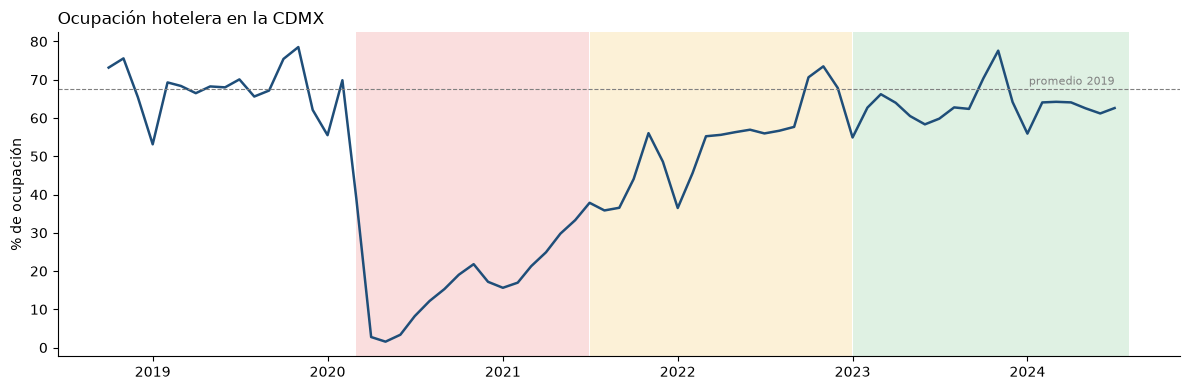

In [56]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 4))
for a, b, c in [("2020-03-01", "2021-06-30", "#f4b6b6"), ("2021-07-01", "2022-12-31", "#f9e0a8"),
                ("2023-01-01", "2024-07-31", "#b9e0c3")]:
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=c, alpha=.45, lw=0)
ax.plot(h["fecha"], h["ocupacion_pct"], color="#1f4e79", lw=1.8)
promedio_2019 = h[h.fecha.dt.year == 2019].ocupacion_pct.mean()
ax.axhline(promedio_2019, color="grey", ls="--", lw=.8)
ax.text(h["fecha"].max(), promedio_2019 + 1, "promedio 2019", ha="right", fontsize=8, color="grey")
ax.set_title("Ocupación hotelera en la CDMX", loc="left")
ax.set_ylabel("% de ocupación")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.spines[["top", "right"]].set_visible(False)
FIGURAS = RAIZ / "informe" / "figuras"
plt.tight_layout()
fig.savefig(FIGURAS / "hoteles_ocupacion.png", dpi=160)
plt.show()

---
## Hechos de tránsito (SSC)

**Objetivo:** una tabla con **cuántos accidentes de cada tipo** ocurrieron **en cada alcaldía y cada mes**, con las personas lesionadas y fallecidas.

| fecha | cve_alcaldia | alcaldia | tipo_evento | total | lesionados | fallecidos |
|---|---|---|---|---:|---:|---:|

**Fuentes:** serie *ampliada* (2018–2023) y serie *2024*. Tienen las mismas columnas pero distinto formato de fecha y hora. Los archivos están en Google Drive: https://drive.google.com/drive/folders/1_Ih0f-9izLZPIRkHpHvWx1OMLO0lkmAK (copiarlos en `data/raw/hechos_transito_ampliada/` y `data/raw/hechos_transito_2024/`).

Cada error que se encuentra en los datos se registra en `errores` y se resume al final de esta sección (**Errores encontrados**).

⚠️ **Limitación:** la serie *no es comparable entre años*: en 2021–2022 los registros suben de ~17 mil a ~30 mil por cambios en la forma de registrar, no por más accidentes.

In [57]:
import sys
from pathlib import Path
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = RAIZ / "data" / "raw"
INTERIM = RAIZ / "data" / "interim"
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
from src.clean.catalogos import cve_por_nombre, cve_por_coordenadas, nombre_alcaldia   # catálogo común

errores = []   # (paso, error encontrado, registros afectados, decisión)

ampliada = pd.read_csv(RAW / "hechos_transito_ampliada" / "hechos_de_transito_registrados_por_la_ssc.csv", low_memory=False)
t2024 = pd.read_csv(RAW / "hechos_transito_2024" / "hechos_de_transito_registrados_por_la_ssc.csv",
                    low_memory=False, encoding="utf-8-sig")
print(f"Ampliada: {len(ampliada):,} filas | 2024: {len(t2024):,} filas | columnas iguales: {list(ampliada.columns) == list(t2024.columns)}")
print("Fecha → ampliada:", ampliada.fecha_evento.iloc[0], "| 2024:", t2024.fecha_evento.iloc[0])
print("Hora  → ampliada:", ampliada.hora_evento.iloc[0], "| 2024:", t2024.hora_evento.iloc[0])

Ampliada: 134,079 filas | 2024: 30,655 filas | columnas iguales: True
Fecha → ampliada: 2020-04-06 | 2024: 01/01/2024
Hora  → ampliada: 12:50:00 | 2024: 08:03


### Paso 1 — Unificar fechas y unir los dos archivos

In [58]:
errores.append(("1. Fechas", "Formato de fecha distinto entre archivos (aaaa-mm-dd vs dd/mm/aaaa) y hora con/sin segundos",
                len(t2024), "Se convierten ambos a fecha con su formato explícito"))

ampliada["fecha_evento"] = pd.to_datetime(ampliada["fecha_evento"], format="%Y-%m-%d", errors="coerce")
t2024["fecha_evento"] = pd.to_datetime(t2024["fecha_evento"], format="%d/%m/%Y", errors="coerce")
ampliada["serie"] = "ampliada"
t2024["serie"] = "2024"
transito = pd.concat([ampliada, t2024], ignore_index=True)

sin_fecha = transito["fecha_evento"].isna().sum()
if sin_fecha:
    errores.append(("1. Fechas", "Fechas que no se pudieron interpretar", sin_fecha, "Se descartan"))
    transito = transito.dropna(subset=["fecha_evento"])

print(f"{len(transito):,} filas · {transito.fecha_evento.min().date()} → {transito.fecha_evento.max().date()} · fechas inválidas: {sin_fecha}")
transito.groupby(transito.fecha_evento.dt.year).size().rename("registros").to_frame()

164,734 filas · 2018-01-01 → 2024-12-31 · fechas inválidas: 0


,registros
fecha_evento,
2018,17028
2019,18014
2020,16440
2021,22860
2022,30704
2023,29033
2024,30655


### Paso 2 — Folios y duplicados
El folio no sirve para contar accidentes: tiene un valor de relleno (`SD` = sin dato) y folios repetidos que corresponden a accidentes distintos (otra hora, otro lugar u otro tipo). Se cuentan **filas**, y los duplicados se detectan con fecha + hora + tipo + coordenadas.

In [59]:
repetidos = transito["folio"].value_counts()
n_sd = int((transito["folio"] == "SD").sum())
sd_2018 = int(((transito["folio"] == "SD") & (transito.fecha_evento.dt.year == 2018)).sum())
errores.append(("2. Folios", "Folio 'SD' (sin dato): faltante disfrazado", n_sd,
                f"Se conservan (son accidentes distintos); {sd_2018:,} son de 2018 → no se usa el folio para contar"))

otros = repetidos.drop("SD", errors="ignore")
otros = otros[otros > 1]
filas_otros = int(transito["folio"].isin(otros.index).sum())
errores.append(("2. Folios", "Folios repetidos con distinta hora, lugar o tipo", filas_otros,
                "Se conservan: son accidentes distintos que comparten folio"))

clave_evento = ["fecha_evento", "hora_evento", "tipo_evento", "latitud", "longitud"]
dup = transito.duplicated(clave_evento, keep="first")
errores.append(("2. Duplicados", "Misma fecha, hora, tipo y coordenadas", int(dup.sum()), "Se eliminan (se deja uno)"))
transito = transito[~dup].copy()

print(f"Folio 'SD': {n_sd:,} | filas con otros folios repetidos: {filas_otros:,} | duplicados eliminados: {dup.sum()}")
print(f"Quedan {len(transito):,} accidentes")

Folio 'SD': 7,288 | filas con otros folios repetidos: 537 | duplicados eliminados: 28
Quedan 164,706 accidentes


### Paso 3 — Alcaldías a clave INEGI

In [60]:
print("Valores originales:", sorted(transito["alcaldia"].dropna().unique()))
vacias = int(transito["alcaldia"].isna().sum())
if vacias:
    errores.append(("3. Alcaldías", "Alcaldía vacía", vacias, "Se asigna por coordenadas"))

transito["cve_alcaldia"] = cve_por_nombre(transito["alcaldia"])

# escrituras que no son la forma estándar del catálogo (errata o abreviatura), pero sí se reconocen
from src.clean.catalogos import normalizar
estandar = {normalizar(n) for n in nombre_alcaldia(pd.Series([f"09{i:03d}" for i in range(2, 18)]))}
no_estandar = transito["alcaldia"].notna() & ~transito["alcaldia"].map(normalizar).isin(estandar) & transito["cve_alcaldia"].notna()
for valor, n in transito.loc[no_estandar, "alcaldia"].value_counts().items():
    errores.append(("3. Alcaldías", f"Nombre no estándar: '{valor}'", int(n), "Se unifica a la clave INEGI con el catálogo"))

sin_cve = transito["cve_alcaldia"].isna()
for valor, n in transito.loc[sin_cve, "alcaldia"].value_counts(dropna=False).items():
    errores.append(("3. Alcaldías", f"No es una alcaldía: '{valor}'", int(n), "Se asigna por coordenadas"))
transito.loc[sin_cve, "cve_alcaldia"] = cve_por_coordenadas(transito.loc[sin_cve, "latitud"], transito.loc[sin_cve, "longitud"])

sin_asignar = int(transito["cve_alcaldia"].isna().sum())
if sin_asignar:
    errores.append(("3. Alcaldías", "Sin alcaldía ni coordenadas dentro de la CDMX", sin_asignar, "Se descartan"))
    transito = transito.dropna(subset=["cve_alcaldia"])

# validación: ¿el nombre coincide con la alcaldía de las coordenadas?
muestra = transito.sample(20_000, random_state=1)
por_coord = cve_por_coordenadas(muestra["latitud"], muestra["longitud"])
ok = por_coord.notna()
iguales = muestra.loc[ok, "cve_alcaldia"] == por_coord[ok]
coincide = iguales.mean()
fuera = int((~ok).sum())
print(f"Coincidencia nombre vs coordenadas (muestra de 20 mil): {coincide:.1%} | coordenadas fuera de la CDMX en la muestra: {fuera}")
errores.append(("3. Alcaldías", f"La alcaldía del nombre no coincide con la de las coordenadas ({1 - coincide:.1%} de la muestra)",
                int((~iguales).sum()),
                "Se conserva la del nombre (la del registro de la SSC); probable efecto de hechos en límites entre alcaldías"))
if fuera:
    errores.append(("3. Alcaldías", "Coordenadas fuera del polígono de la CDMX (muestra de 20 mil)", fuera,
                    "Se conserva la alcaldía del nombre; las coordenadas no se usan"))

transito["alcaldia_oficial"] = nombre_alcaldia(transito["cve_alcaldia"])
transito["alcaldia_oficial"].value_counts()

Valores originales: ['ALVARO OBREGON', 'AV INSURGENTES', 'AZCAPOTZALCO', 'BENITO JUAREZ', 'COYOACAN', 'CUAHUTEMOC', 'CUAJIMALPA', 'CUAUHTEMOC', 'GUSTAVO A MADERO', 'GUSTAVO A. MADERO', 'IZTACALCO', 'IZTAPALAPA', 'MAGDALENA CONTRERAS', 'MIGUEL HIDALGO', 'MILPA ALTA', 'TLAHUAC', 'TLALPAN', 'VENUSTIANO CARRANZA', 'XOCHIMILCO']


Coincidencia nombre vs coordenadas (muestra de 20 mil): 95.8% | coordenadas fuera de la CDMX en la muestra: 40


alcaldia_oficial
Cuauhtémoc                24017
Iztapalapa                23254
Gustavo A. Madero         18442
Benito Juárez             12997
Venustiano Carranza       12298
Miguel Hidalgo            12184
Coyoacán                  11293
Álvaro Obregón             9776
Tlalpan                    9289
Azcapotzalco               7717
Iztacalco                  7672
Tláhuac                    5238
Xochimilco                 5171
Cuajimalpa de Morelos      2188
La Magdalena Contreras     2046
Milpa Alta                 1124
Name: count, dtype: int64

### Paso 4 — Tipo de accidente, lesionados y fallecidos

In [61]:
print(transito["tipo_evento"].value_counts(dropna=False).to_string())
sin_tipo = int(transito["tipo_evento"].isna().sum())
if sin_tipo:
    errores.append(("4. Tipo", "Tipo de accidente vacío", sin_tipo, "Se descartan"))
    transito = transito.dropna(subset=["tipo_evento"])

for c in ["personas_lesionadas", "personas_fallecidas"]:
    valores = pd.to_numeric(transito[c], errors="coerce")
    malos = int(valores.isna().sum() + (valores < 0).sum())
    if malos:
        errores.append(("4. Personas", f"{c}: vacío, no numérico o negativo", malos, "Se toma como 0"))
    transito[c] = valores.clip(lower=0).fillna(0)
    print(f"{c}: vacíos/no válidos {malos} | máximo {transito[c].max():.0f}")

tipo_evento
CHOQUE               95000
DERRAPADO            30803
ATROPELLADO          29661
CAIDA DE CICLISTA     3911
VOLCADURA             2779
CAIDA DE PASAJERO     2552
personas_lesionadas: vacíos/no válidos 0 | máximo 42
personas_fallecidas: vacíos/no válidos 0 | máximo 10


### Paso 5 — Agrupar por mes, alcaldía y tipo
Se arma la cuadrícula completa (todos los meses × 16 alcaldías × 6 tipos): las combinaciones sin accidentes quedan en **0**, porque no es un dato faltante, es que no hubo.

In [62]:
transito["fecha"] = transito["fecha_evento"].dt.to_period("M").dt.to_timestamp()   # primer día del mes

agrupado = (transito.groupby(["fecha", "cve_alcaldia", "tipo_evento"])
                    .agg(total=("tipo_evento", "size"),
                         lesionados=("personas_lesionadas", "sum"),
                         fallecidos=("personas_fallecidas", "sum")))
cuadricula = pd.MultiIndex.from_product(
    [pd.date_range(transito.fecha.min(), transito.fecha.max(), freq="MS"),
     sorted(transito.cve_alcaldia.unique()),
     sorted(transito.tipo_evento.unique())],
    names=["fecha", "cve_alcaldia", "tipo_evento"])
agrupado = agrupado.reindex(cuadricula, fill_value=0).reset_index()
agrupado["alcaldia"] = nombre_alcaldia(agrupado["cve_alcaldia"])
agrupado["serie"] = agrupado["fecha"].dt.year.map(lambda a: "2024" if a == 2024 else "ampliada")
agrupado[["total", "lesionados", "fallecidos"]] = agrupado[["total", "lesionados", "fallecidos"]].astype(int)
agrupado = agrupado[["fecha", "cve_alcaldia", "alcaldia", "tipo_evento", "total", "lesionados", "fallecidos", "serie"]]

print(f"{len(agrupado):,} filas = {agrupado.fecha.nunique()} meses × {agrupado.cve_alcaldia.nunique()} alcaldías × {agrupado.tipo_evento.nunique()} tipos")
print("Combinaciones sin accidentes (0):", (agrupado.total == 0).sum())
print("¿Cuadra el total con los accidentes limpios?", agrupado.total.sum() == len(transito), f"({agrupado.total.sum():,})")
agrupado.head(12)

8,064 filas = 84 meses × 16 alcaldías × 6 tipos
Combinaciones sin accidentes (0): 1140
¿Cuadra el total con los accidentes limpios? True (164,706)


,fecha,cve_alcaldia,alcaldia,tipo_evento,total,lesionados,fallecidos,serie
0,2018-01-01,09002,Azcapotzalco,ATROPELLADO,8,8,0,ampliada
1,2018-01-01,09002,Azcapotzalco,CAIDA DE CICLISTA,1,1,0,ampliada
2,2018-01-01,09002,Azcapotzalco,CAIDA DE PASAJERO,1,1,0,ampliada
3,2018-01-01,09002,Azcapotzalco,CHOQUE,28,33,1,ampliada
4,2018-01-01,09002,Azcapotzalco,DERRAPADO,8,8,1,ampliada
5,2018-01-01,09002,Azcapotzalco,VOLCADURA,0,0,0,ampliada
6,2018-01-01,09003,Coyoacán,ATROPELLADO,22,22,1,ampliada
7,2018-01-01,09003,Coyoacán,CAIDA DE CICLISTA,1,1,0,ampliada
8,2018-01-01,09003,Coyoacán,CAIDA DE PASAJERO,4,4,0,ampliada
9,2018-01-01,09003,Coyoacán,CHOQUE,44,59,0,ampliada


### Resultado y guardado

In [63]:
anual = agrupado.pivot_table(index=agrupado.fecha.dt.year, columns="tipo_evento", values="total", aggfunc="sum")
anual["TOTAL"] = anual.sum(axis=1)
anual["lesionados"] = agrupado.groupby(agrupado.fecha.dt.year).lesionados.sum()
anual["fallecidos"] = agrupado.groupby(agrupado.fecha.dt.year).fallecidos.sum()
display(anual)

agrupado.to_csv(INTERIM / "transito_alcaldia_mes.csv", index=False, encoding="utf-8-sig")
agrupado.to_parquet(INTERIM / "transito_alcaldia_mes.parquet", index=False)
print("Guardado: data/interim/transito_alcaldia_mes.csv (y .parquet)")

tipo_evento,ATROPELLADO,CAIDA DE CICLISTA,CAIDA DE PASAJERO,CHOQUE,DERRAPADO,VOLCADURA,TOTAL,lesionados,fallecidos
fecha,,,,,,,,,
2018,4297,156,304,9608,2396,264,17025,19995,394
2019,5086,133,299,8471,3657,368,18014,20841,397
2020,2761,544,238,9251,3358,288,16440,18512,388
2021,3468,762,303,13445,4427,450,22855,26284,424
2022,4676,845,391,18523,5786,481,30702,36321,533
2023,4552,711,406,17593,5313,445,29020,34010,472
2024,4821,760,611,18109,5866,483,30650,36260,533


Guardado: data/interim/transito_alcaldia_mes.csv (y .parquet)


### Tabla diaria (por si se requiere)
Los mismos accidentes limpios, agregados por **día × alcaldía × tipo**. Se arma la cuadrícula completa (2,557 días × 16 alcaldías × 6 tipos = 245,472 filas, dentro del límite de Excel). Las combinaciones sin accidentes quedan en **0**.

Antes se revisa, igual que con el Metro, si hay días **sin registro** o con **muy pocos registros** para toda la CDMX. Para eso se compara el total del día con la mediana móvil de 29 días.

In [64]:
from src.clean.catalogos import guardar

transito["dia"] = transito["fecha_evento"].dt.normalize()
todos_los_dias = pd.date_range(transito.dia.min(), transito.dia.max())
por_dia = transito.groupby("dia").size().reindex(todos_los_dias, fill_value=0)
ratio_dia = por_dia / por_dia.rolling(29, center=True, min_periods=10).median()
dias_bajos = ratio_dia[ratio_dia < 0.4].index

print(f"Días sin ningún registro: {(por_dia == 0).sum()} de {len(por_dia):,}")
print(f"Accidentes por día en la CDMX: mediana {por_dia.median():.0f}, mín {por_dia.min()}, máx {por_dia.max()}")
print("Días con menos del 40 % de lo normal:")
pd.DataFrame({"accidentes": por_dia[dias_bajos], "% de lo normal": (ratio_dia[dias_bajos] * 100).round(0)})

Días sin ningún registro: 0 de 2,557
Accidentes por día en la CDMX: mediana 63, mín 4, máx 134
Días con menos del 40 % de lo normal:


,accidentes,% de lo normal
2018-05-07,4,14.0
2018-05-09,9,31.0
2018-06-27,21,38.0
2018-08-12,18,29.0
2020-06-09,14,39.0
2021-10-06,20,28.0
2023-06-26,10,12.0


No falta ningún día, pero hay 7 días con muy pocos registros (por ejemplo, 4 accidentes el 7-may-2018 y 10 el 26-jun-2023, cuando lo normal es ~30 y ~80). En general no coinciden con festivos ni con el confinamiento, así que lo más probable es un **registro incompleto** de ese día. Se **conservan** y se marcan con `registro_bajo = True` para poder excluirlos si se analiza por día. En la tabla mensual su efecto es pequeño.

In [65]:
errores.append(("Tabla diaria", f"{len(dias_bajos)} días con menos del 40 % de los registros normales (p. ej. 7-may-2018 y 26-jun-2023)",
                int(por_dia[dias_bajos].sum()), "Se conservan y se marcan con registro_bajo = True"))

diario = (transito.groupby(["dia", "cve_alcaldia", "tipo_evento"])
                  .agg(total=("tipo_evento", "size"),
                       lesionados=("personas_lesionadas", "sum"),
                       fallecidos=("personas_fallecidas", "sum")))
cuadricula_dia = pd.MultiIndex.from_product(
    [todos_los_dias, sorted(transito.cve_alcaldia.unique()), sorted(transito.tipo_evento.unique())],
    names=["fecha", "cve_alcaldia", "tipo_evento"])
diario = diario.rename_axis(["fecha", "cve_alcaldia", "tipo_evento"]).reindex(cuadricula_dia, fill_value=0).reset_index()
diario["alcaldia"] = nombre_alcaldia(diario["cve_alcaldia"])
diario["serie"] = diario["fecha"].dt.year.map(lambda a: "2024" if a == 2024 else "ampliada")
diario["registro_bajo"] = diario["fecha"].isin(dias_bajos)
diario[["total", "lesionados", "fallecidos"]] = diario[["total", "lesionados", "fallecidos"]].astype(int)
diario = diario[["fecha", "cve_alcaldia", "alcaldia", "tipo_evento", "total", "lesionados", "fallecidos", "serie", "registro_bajo"]]

# validación: la tabla diaria debe sumar lo mismo que la mensual
mensual_desde_diario = diario.groupby(diario.fecha.dt.to_period("M").dt.to_timestamp())[["total", "lesionados", "fallecidos"]].sum()
mensual_original = agrupado.groupby("fecha")[["total", "lesionados", "fallecidos"]].sum()
print(f"{len(diario):,} filas = {diario.fecha.nunique():,} días × {diario.cve_alcaldia.nunique()} alcaldías × {diario.tipo_evento.nunique()} tipos")
print("Combinaciones sin accidentes (0):", f"{(diario.total == 0).sum():,}")
print("¿Cuadra con la tabla mensual (total, lesionados y fallecidos, mes por mes)?", mensual_desde_diario.equals(mensual_original))
guardar(diario, "transito_alcaldia_dia")
diario[diario.total > 0].head(8)

245,472 filas = 2,557 días × 16 alcaldías × 6 tipos
Combinaciones sin accidentes (0): 169,817
¿Cuadra con la tabla mensual (total, lesionados y fallecidos, mes por mes)? True


  → data/interim/transito_alcaldia_dia.csv / .parquet (245,472 filas)


,fecha,cve_alcaldia,alcaldia,tipo_evento,total,lesionados,fallecidos,serie,registro_bajo
3,2018-01-01,09002,Azcapotzalco,CHOQUE,1,1,0,ampliada,False
4,2018-01-01,09002,Azcapotzalco,DERRAPADO,1,0,1,ampliada,False
9,2018-01-01,09003,Coyoacán,CHOQUE,1,1,0,ampliada,False
18,2018-01-01,09005,Gustavo A. Madero,ATROPELLADO,1,0,1,ampliada,False
20,2018-01-01,09005,Gustavo A. Madero,CAIDA DE PASAJERO,1,1,0,ampliada,False
21,2018-01-01,09005,Gustavo A. Madero,CHOQUE,4,6,0,ampliada,False
22,2018-01-01,09005,Gustavo A. Madero,DERRAPADO,1,1,0,ampliada,False
23,2018-01-01,09005,Gustavo A. Madero,VOLCADURA,1,1,0,ampliada,False


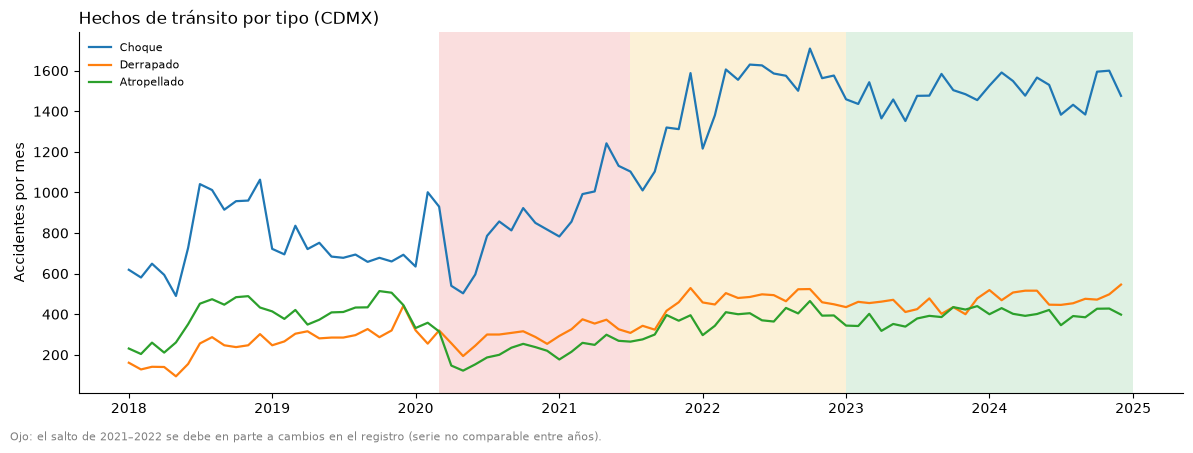

In [66]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

mensual = agrupado.pivot_table(index="fecha", columns="tipo_evento", values="total", aggfunc="sum")
fig, ax = plt.subplots(figsize=(12, 4.5))
for a, b, c in [("2020-03-01", "2021-06-30", "#f4b6b6"), ("2021-07-01", "2022-12-31", "#f9e0a8"),
                ("2023-01-01", "2024-12-31", "#b9e0c3")]:
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=c, alpha=.45, lw=0)
for tipo in ["CHOQUE", "DERRAPADO", "ATROPELLADO"]:
    ax.plot(mensual.index, mensual[tipo], lw=1.6, label=tipo.capitalize())
ax.set_title("Hechos de tránsito por tipo (CDMX)", loc="left")
ax.set_ylabel("Accidentes por mes")
ax.legend(frameon=False, fontsize=8, loc="upper left")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.spines[["top", "right"]].set_visible(False)
fig.text(0.01, 0.01, "Ojo: el salto de 2021–2022 se debe en parte a cambios en el registro (serie no comparable entre años).",
         fontsize=8, color="grey")
FIGURAS = RAIZ / "informe" / "figuras"
plt.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig(FIGURAS / "transito_tipos_mes.png", dpi=160)
plt.show()

### Visualización

**1. Peatones y ciclistas.** Atropellados y caídas de ciclista por mes. Se esperaba que dependieran menos del cambio de registro de 2021–2022 que los choques, pero la gráfica muestra otros dos cortes de registro (ver la interpretación abajo).

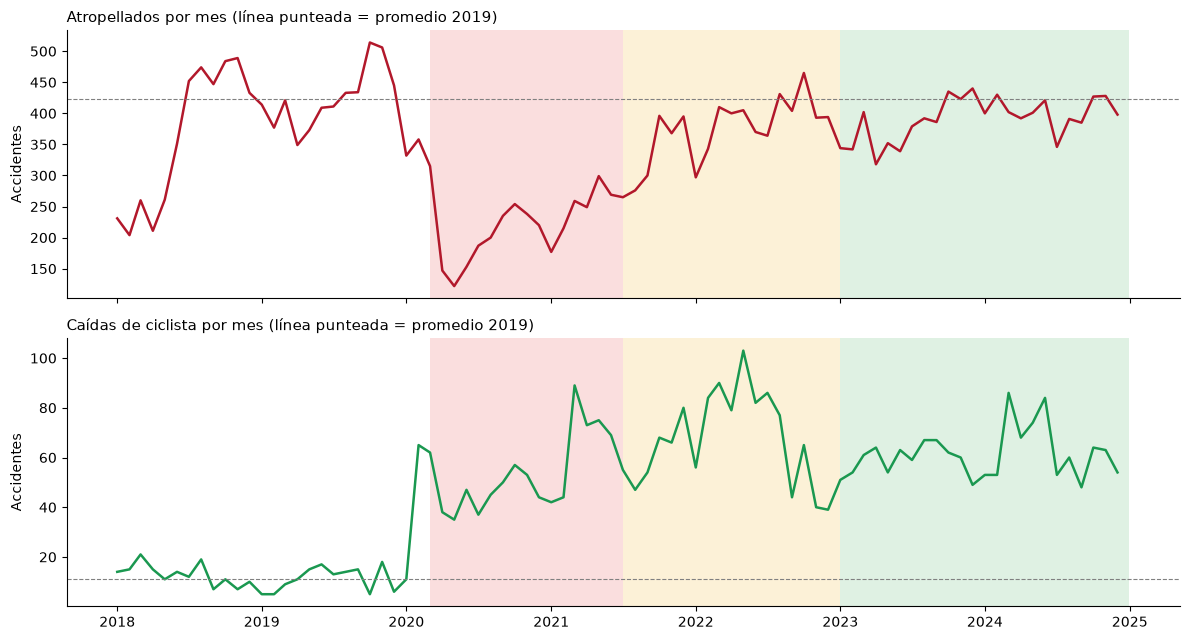

In [67]:
PERIODOS_T = [("2020-03-01", "2021-06-30", "#f4b6b6"), ("2021-07-01", "2022-12-31", "#f9e0a8"),
              ("2023-01-01", "2024-12-31", "#b9e0c3")]

def sombrear_t(ax):
    for a, b, c in PERIODOS_T:
        ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=c, alpha=.45, lw=0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)
for ax, tipo, color, titulo in [(ax1, "ATROPELLADO", "#b2182b", "Atropellados"),
                                (ax2, "CAIDA DE CICLISTA", "#1a9850", "Caídas de ciclista")]:
    sombrear_t(ax)
    ax.plot(mensual.index, mensual[tipo], color=color, lw=1.8)
    ax.axhline(mensual.loc["2019", tipo].mean(), color="grey", ls="--", lw=.8)
    ax.set_title(f"{titulo} por mes (línea punteada = promedio 2019)", loc="left", fontsize=11)
    ax.set_ylabel("Accidentes")
    ax.spines[["top", "right"]].set_visible(False)
ax2.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
fig.savefig(FIGURAS / "transito_peatones_ciclistas.png", dpi=160)
plt.show()

**2. Cambio por alcaldía.** Atropellados de cada año como porcentaje de 2019 (100 = igual que antes de la pandemia). Sirve para la hipótesis H4: ¿la caída y la recuperación fueron iguales en todas las alcaldías?

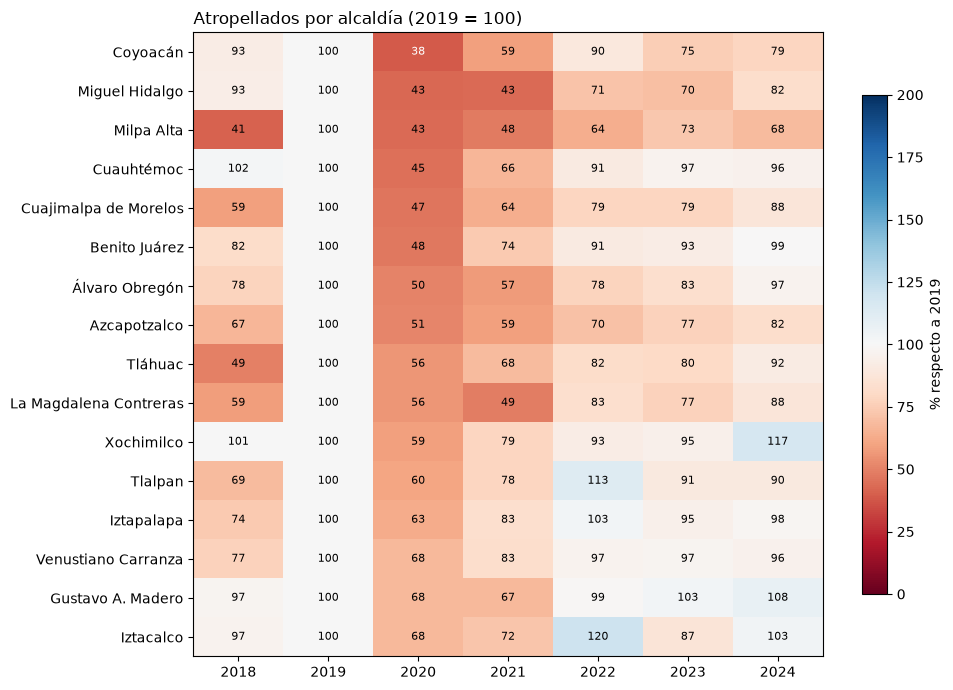

Caída en 2020 (atropellados, % de 2019):
alcaldia
Coyoacán                  38.0
Miguel Hidalgo            43.0
Milpa Alta                43.0
Cuauhtémoc                45.0
Cuajimalpa de Morelos     47.0
Benito Juárez             48.0
Álvaro Obregón            50.0
Azcapotzalco              51.0
Tláhuac                   56.0
La Magdalena Contreras    56.0
Xochimilco                59.0
Tlalpan                   60.0
Iztapalapa                63.0
Venustiano Carranza       68.0
Gustavo A. Madero         68.0
Iztacalco                 68.0


In [68]:
import numpy as np

atrop = (agrupado[agrupado.tipo_evento == "ATROPELLADO"]
         .pivot_table(index="alcaldia", columns=agrupado.fecha.dt.year, values="total", aggfunc="sum"))
indice_alc = atrop.div(atrop[2019], axis=0) * 100
indice_alc = indice_alc.sort_values(2020)          # de la que más cayó en 2020 a la que menos

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(indice_alc.values, cmap="RdBu", vmin=0, vmax=200, aspect="auto")
ax.set_xticks(range(indice_alc.shape[1]), indice_alc.columns)
ax.set_yticks(range(indice_alc.shape[0]), indice_alc.index)
for i in range(indice_alc.shape[0]):
    for j in range(indice_alc.shape[1]):
        v = indice_alc.values[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8,
                color="white" if abs(v - 100) > 60 else "black")
ax.set_title("Atropellados por alcaldía (2019 = 100)", loc="left")
fig.colorbar(im, ax=ax, label="% respecto a 2019", shrink=.8)
plt.tight_layout()
fig.savefig(FIGURAS / "transito_atropellados_alcaldia.png", dpi=160)
plt.show()

print("Caída en 2020 (atropellados, % de 2019):")
print(indice_alc[2020].round(0).sort_values().to_string())

**3. Gravedad.** Personas fallecidas por año y tipo de accidente.

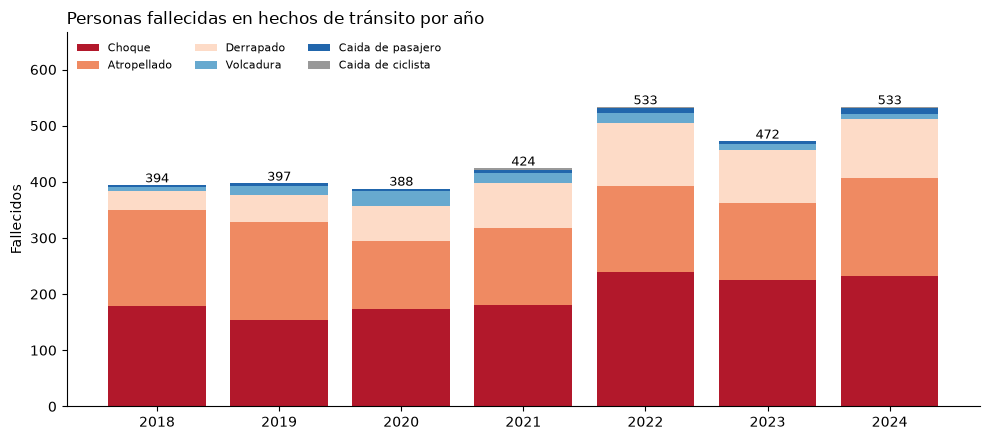

tipo_evento,ATROPELLADO,CAIDA DE CICLISTA,CAIDA DE PASAJERO,CHOQUE,DERRAPADO,VOLCADURA,TOTAL
fecha,,,,,,,
2018,171,0,3,179,33,8,394
2019,174,0,5,154,49,15,397
2020,121,1,4,173,63,26,388
2021,137,3,5,181,79,19,424
2022,154,2,9,239,112,17,533
2023,138,0,4,225,93,12,472
2024,173,2,10,233,106,9,533


In [69]:
fall = agrupado.pivot_table(index=agrupado.fecha.dt.year, columns="tipo_evento", values="fallecidos", aggfunc="sum")
orden = fall.sum().sort_values(ascending=False).index
colores = ["#b2182b", "#ef8a62", "#fddbc7", "#67a9cf", "#2166ac", "#999999"]

fig, ax = plt.subplots(figsize=(10, 4.5))
abajo = np.zeros(len(fall))
for tipo, color in zip(orden, colores):
    ax.bar(fall.index, fall[tipo], bottom=abajo, color=color, label=tipo.capitalize())
    abajo += fall[tipo].values
for x, total in zip(fall.index, abajo):
    ax.text(x, total + 5, f"{total:.0f}", ha="center", fontsize=9)
ax.set_title("Personas fallecidas en hechos de tránsito por año", loc="left")
ax.set_ylabel("Fallecidos")
ax.legend(frameon=False, fontsize=8, ncols=3, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, abajo.max() * 1.25)
plt.tight_layout()
fig.savefig(FIGURAS / "transito_fallecidos.png", dpi=160)
plt.show()
fall.assign(TOTAL=fall.sum(axis=1)).astype(int)

### Interpretación y problemas detectados en las gráficas
- **Atropellados:** cayeron ~70 % en abril–mayo de 2020 respecto al promedio de 2019 y en 2024 volvieron a ~95 %. Es el indicador más confiable de esta fuente.
- **Caídas de ciclista:** saltan de ~11 a ~65 al mes en **febrero de 2020, antes del confinamiento** (23-mar-2020). Un cambio así de brusco y previo a la pandemia apunta a un **cambio en la forma de registrar** este tipo de accidente, no a más ciclistas. No se debe usar para comparar antes y después.
- **Primer semestre de 2018:** los atropellados son la mitad que en el segundo semestre (~230 vs ~450 al mes), y en 2018 el 43 % de los registros no tiene folio. Parece un **registro incompleto**: la línea base debe ser **2019**, no 2018 (en el mapa de calor, los valores bajos de 2018 no son reales).
- **Por alcaldía (H4):** en 2020 la caída fue mayor en alcaldías centrales y de oficinas (Coyoacán 38, Miguel Hidalgo 43, Cuauhtémoc 45, Benito Juárez 48) que en las periféricas y populares (Iztapalapa 63, Gustavo A. Madero 68, Iztacalco 68). Es coherente con H4: donde más se pudo trabajar desde casa, menos gente salió a la calle.
- **Fallecidos:** estables en ~395 al año entre 2018 y 2020 y más altos desde 2022 (hasta 533). Crecen sobre todo los *derrapados* (33 → 106), típicamente de motocicleta, pero parte del aumento puede ser el cambio de registro.

In [70]:
# se agregan a la tabla de errores los problemas detectados en las gráficas
at = mensual["ATROPELLADO"]
ci = mensual["CAIDA DE CICLISTA"]
errores.append(("Gráficas", "Caídas de ciclista: salto de registro en feb-2020, antes del confinamiento "
                f"({ci['2019'].mean():.0f} → {ci['2020-02':'2020-12'].mean():.0f} al mes)",
                int(ci["2020-02":].sum()), "No se usa para comparar antes y después de la pandemia"))
errores.append(("Gráficas", "Primer semestre de 2018 incompleto (atropellados "
                f"{at['2018-01':'2018-06'].mean():.0f} vs {at['2018-07':'2018-12'].mean():.0f} al mes)",
                int(agrupado.loc[agrupado.fecha.between('2018-01-01', '2018-06-01'), 'total'].sum()),
                "La línea base es 2019, no 2018"))
print(f"Atropellados: promedio 2019 = {at['2019'].mean():.0f}/mes · abr–may 2020 = {at['2020-04':'2020-05'].mean():.0f} "
      f"({at['2020-04':'2020-05'].mean() / at['2019'].mean() - 1:.0%}) · 2024 = {at['2024'].mean() / at['2019'].mean():.0%} de 2019")

Atropellados: promedio 2019 = 424/mes · abr–may 2020 = 134 (-68%) · 2024 = 95% de 2019


### Errores encontrados en la limpieza (hechos de tránsito)
Resumen de todos los problemas detectados en los pasos anteriores, cuántos registros afectaron y qué se decidió.

In [71]:
tabla_errores = pd.DataFrame(errores, columns=["paso", "error encontrado", "registros", "decisión"])
pd.set_option("display.max_colwidth", 120)
tabla_errores

,paso,error encontrado,registros,decisión
0,1. Fechas,Formato de fecha distinto entre archivos (aaaa-mm-dd vs dd/mm/aaaa) y hora con/sin segundos,30655,Se convierten ambos a fecha con su formato explícito
1,2. Folios,Folio 'SD' (sin dato): faltante disfrazado,7288,"Se conservan (son accidentes distintos); 7,274 son de 2018 → no se usa el folio para contar"
2,2. Folios,"Folios repetidos con distinta hora, lugar o tipo",537,Se conservan: son accidentes distintos que comparten folio
3,2. Duplicados,"Misma fecha, hora, tipo y coordenadas",28,Se eliminan (se deja uno)
4,3. Alcaldías,Nombre no estándar: 'GUSTAVO A MADERO',18441,Se unifica a la clave INEGI con el catálogo
5,3. Alcaldías,Nombre no estándar: 'CUAJIMALPA',2188,Se unifica a la clave INEGI con el catálogo
6,3. Alcaldías,Nombre no estándar: 'MAGDALENA CONTRERAS',2046,Se unifica a la clave INEGI con el catálogo
7,3. Alcaldías,Nombre no estándar: 'CUAHUTEMOC',1,Se unifica a la clave INEGI con el catálogo
8,3. Alcaldías,No es una alcaldía: 'AV INSURGENTES',1,Se asigna por coordenadas
9,3. Alcaldías,La alcaldía del nombre no coincide con la de las coordenadas (4.2% de la muestra),845,Se conserva la del nombre (la del registro de la SSC); probable efecto de hechos en límites entre alcaldías


---
## Afluencia del Metro (STC)

**Objetivo:** dejar la afluencia diaria por estación **sin errores de codificación, nombres ni duplicados**, distinguir los tres tipos de ceros (estación que no existía, día sin conteo y estación cerrada) y marcar los cierres de las Líneas 1 y 12 para no confundirlos con el efecto de la pandemia.

**Fuente:** `afluencia_metro_simple.csv` (2010-01 → 2026-07, día × estación). La versión *desglosada* (por tipo de pago, solo desde 2021) suma exactamente lo mismo día por día, así que no se usa para la serie.

**Salidas** (`data/interim/`): `metro_linea_dia`, `metro_estacion_mes` y `metro_mes`.

### Exploración inicial

In [72]:
import sys
from pathlib import Path
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = RAIZ / "data" / "raw"
INTERIM = RAIZ / "data" / "interim"
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

df= pd.read_csv(RAW/"metro"/"afluencia_metro_simple.csv")
df

,fecha,anio,mes,linea,estacion,afluencia
0,2010-01-01,2010,Enero,Linea 1,Zaragoza,20227
1,2010-01-01,2010,Enero,Linea 1,Isabel la CatÃ³lica,6487
2,2010-01-01,2010,Enero,Linea 1,Moctezuma,10304
3,2010-01-01,2010,Enero,Linea 1,Pino SuÃ¡rez,8679
4,2010-01-01,2010,Enero,Linea 1,GÃ³mez FarÃ­as,19499
...,...,...,...,...,...,...
1180915,2026-07-31,2026,Julio,Linea B,Romero Rubio,14133
1180916,2026-07-31,2026,Julio,Linea B,RÃ­o de los Remedios,15731
1180917,2026-07-31,2026,Julio,Linea B,San LÃ¡zaro,14055
1180918,2026-07-31,2026,Julio,Linea B,Tepito,19387


Primero se revisa la afluencia total por año con los datos **crudos**, en especial la de 2020.

In [73]:

afluencia_por_anio=df[["anio","afluencia"]]
afluencia_por_anio

,anio,afluencia
0,2010,20227
1,2010,6487
2,2010,10304
3,2010,8679
4,2010,19499
...,...,...
1180915,2026,14133
1180916,2026,15731
1180917,2026,14055
1180918,2026,19387


In [74]:
afluencia_por_anio=afluencia_por_anio.groupby('anio')['afluencia'].sum()
afluencia_por_anio

anio
2010    1530248597
2011    1594903897
2012    1608865175
2013    1684936618
2014    1614333594
2015    1623828642
2016    1662562714
2017    1615652411
2018    1647475013
2019    1594651279
2020     894224342
2021     794299549
2022    1030108295
2023    1115299291
2024    1171859113
2025    1255370592
2026     716497143
Name: afluencia, dtype: int64

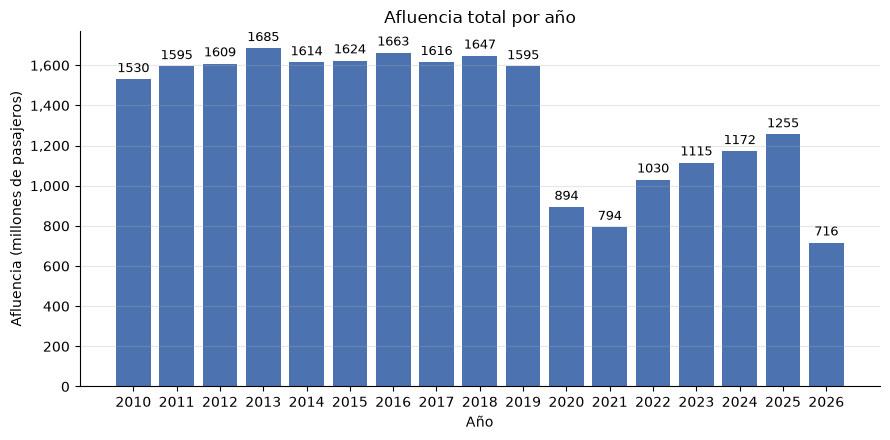

In [75]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

afluencia_por_anio = (
    df.groupby("anio", as_index=False)["afluencia"]
      .sum()
      .sort_values("anio")
)
fig, ax = plt.subplots(figsize=(9, 4.5))
barras = ax.bar(afluencia_por_anio["anio"].astype(str),
                afluencia_por_anio["afluencia"] / 1e6,
                color="#4C72B0")

ax.bar_label(barras, fmt="%.0f", padding=3, fontsize=9)
ax.set_title("Afluencia total por año")
ax.set_xlabel("Año")
ax.set_ylabel("Afluencia (millones de pasajeros)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Paso 1 — Codificación (*mojibake*) y nombres de línea
El archivo viene con texto mal codificado (`CatÃ³lica` en vez de `Católica`) y la columna `linea` tiene **24 valores para 12 líneas**: `Linea 1` en unos años y `LÃ­nea 1` en otros. Se repara con `ftfy` y se unifica a `Línea N` (la misma escritura que en el Metrobús).

Cada error que se encuentra se registra en `errores` y se resume al final de la sección.

In [76]:
import ftfy
from src.clean.catalogos import guardar

errores = []   # (paso, error encontrado, registros afectados, decisión)

metro = df.copy()
metro["fecha"] = pd.to_datetime(metro["fecha"], format="%Y-%m-%d")

lineas_antes = metro["linea"].nunique()
mojibake_linea = metro["linea"].str.contains("Ã")
anios = metro.loc[mojibake_linea, "fecha"].dt.year
errores.append(("1. Codificación", f"Línea escrita 'LÃ­nea N' ({anios.min()}–{anios.max()}) y 'Linea N' (resto de años)",
                int(mojibake_linea.sum()), "Se repara y se unifica a 'Línea N'"))
metro["linea"] = metro["linea"].map(ftfy.fix_text).str.replace(r"^L[ií]nea", "Línea", regex=True)

estaciones_antes = metro["estacion"].nunique()
reparada = metro["estacion"].map(ftfy.fix_text)
errores.append(("1. Codificación", "Nombre de estación con mojibake ('CatÃ³lica')",
                int((reparada != metro["estacion"]).sum()), "Se repara con ftfy"))
metro["estacion"] = reparada

print(f"Líneas: {lineas_antes} → {metro.linea.nunique()}  {sorted(metro.linea.unique())}")
print(f"Nombres de estación: {estaciones_antes} → {metro.estacion.nunique()}")

Líneas: 24 → 12  ['Línea 1', 'Línea 12', 'Línea 2', 'Línea 3', 'Línea 4', 'Línea 5', 'Línea 6', 'Línea 7', 'Línea 8', 'Línea 9', 'Línea A', 'Línea B']
Nombres de estación: 168 → 165


### Paso 2 — Estaciones escritas de dos formas
Después de reparar la codificación quedan dos estaciones que **cambian de escritura a partir de junio de 2023**. Si no se unifican, cada una queda partida en dos series.

In [77]:
import unicodedata
sin_acentos = lambda s: unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode().upper()
nombres = pd.Series(metro["estacion"].unique())
grupos = nombres.groupby(nombres.map(sin_acentos)).agg(list)
print("Mismo nombre, distinta escritura:", grupos[grupos.map(len) > 1].tolist())

VARIANTES = {"Gómez Farias": "Gómez Farías", "Peñón viejo": "Peñón Viejo"}
for mal, bien in VARIANTES.items():
    filas = metro["estacion"] == mal
    errores.append(("2. Estaciones", f"'{mal}' en vez de '{bien}' (desde {metro.loc[filas, 'fecha'].min():%Y-%m})",
                    int(filas.sum()), "Se unifica a la escritura anterior"))
metro["estacion"] = metro["estacion"].replace(VARIANTES)

por_linea = metro.groupby("linea")["estacion"].nunique()
print(f"Estaciones por línea: {por_linea.to_dict()}")
print(f"Total estación × línea: {por_linea.sum()} (las de correspondencia cuentan una vez por línea)")

Mismo nombre, distinta escritura: [['Gómez Farías', 'Gómez Farias'], ['Peñón Viejo', 'Peñón viejo']]


Estaciones por línea: {'Línea 1': 20, 'Línea 12': 20, 'Línea 2': 24, 'Línea 3': 21, 'Línea 4': 10, 'Línea 5': 13, 'Línea 6': 11, 'Línea 7': 14, 'Línea 8': 19, 'Línea 9': 12, 'Línea A': 10, 'Línea B': 21}
Total estación × línea: 195 (las de correspondencia cuentan una vez por línea)


### Paso 3 — Duplicados
Debe haber **un registro por día, línea y estación**. Se buscan combinaciones repetidas.

In [78]:
clave = ["fecha", "linea", "estacion"]
repetidos = metro[metro.duplicated(clave, keep=False)]
print(repetidos.groupby([repetidos.fecha.dt.strftime("%Y-%m"), "linea", "estacion"]).size().rename("filas").to_frame())

# En diciembre de 2020 "Oceanía" aparece dos veces por día y "Deportivo Oceanía" no aparece.
# Se compara cada registro con el promedio de las dos estaciones en noviembre y enero.
b = metro[(metro.linea == "Línea B") & metro.estacion.isin(["Oceanía", "Deportivo Oceanía"])
          & metro.fecha.between("2020-11-01", "2021-01-31")]
comparacion = b[b.fecha.dt.month != 12].pivot_table(index=b.fecha.dt.strftime("%Y-%m"), columns="estacion",
                                                    values="afluencia", aggfunc="mean").round()
dic = b[b.fecha.dt.month == 12]
comparacion.loc["2020-12 (1.er registro)"] = [None, dic.groupby("fecha").afluencia.first().mean().round()]
comparacion.loc["2020-12 (2.º registro)"] = [None, dic.groupby("fecha").afluencia.last().mean().round()]
comparacion

                          filas
fecha   linea   estacion       
2020-12 Línea B Oceanía      62


estacion,Deportivo Oceanía,Oceanía
fecha,,
2020-11,7310.0,5625.0
2021-01,5809.0,5521.0
2020-12 (1.er registro),NaN,5307.0
2020-12 (2.º registro),NaN,7054.0


El **segundo registro** (≈7 mil) se parece a *Deportivo Oceanía* (≈7.3 mil en noviembre) y el primero a *Oceanía* (≈5.6 mil). Además, en el archivo el segundo aparece justo después de Oceanía, que es el lugar de Deportivo Oceanía en el orden de la Línea B. Es un **error de etiqueta**, no un duplicado: se reasigna en vez de borrarse.

In [79]:
segundo = metro.duplicated(clave, keep="first")
errores.append(("3. Duplicados", "Línea B, dic-2020: 'Oceanía' aparece dos veces por día y falta 'Deportivo Oceanía'",
                int(segundo.sum()), "El 2.º registro (≈7 mil, igual que Deportivo Oceanía) se reasigna a esa estación"))
metro.loc[segundo, "estacion"] = "Deportivo Oceanía"
print("Duplicados restantes:", metro.duplicated(clave).sum())

Duplicados restantes: 0


### Paso 4 — Fechas, calendario y columnas redundantes
Se revisa que `anio` y `mes` coincidan con `fecha`, que no falten días y que cada día tenga las 195 estaciones.

In [80]:
MESES = {m: i for i, m in enumerate(["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", "Julio", "Agosto",
                                     "Septiembre", "Octubre", "Noviembre", "Diciembre"], 1)}
no_coinciden = ((metro.anio != metro.fecha.dt.year) | (metro.mes.map(MESES) != metro.fecha.dt.month)).sum()
dias_faltantes = pd.date_range(metro.fecha.min(), metro.fecha.max()).difference(metro.fecha.unique())
filas_por_dia = metro.groupby("fecha").size()

print(f"Periodo: {metro.fecha.min().date()} → {metro.fecha.max().date()}")
print(f"anio/mes que no coinciden con la fecha: {no_coinciden}")
print(f"Días faltantes en el calendario: {len(dias_faltantes)}")
print(f"Estaciones por día: mín {filas_por_dia.min()}, máx {filas_por_dia.max()}")
print(f"Vacíos: {metro.afluencia.isna().sum()} | negativos: {(metro.afluencia < 0).sum()} | ceros: {(metro.afluencia == 0).sum():,}")

metro = metro.drop(columns=["anio", "mes"])   # se obtienen de la fecha

Periodo: 2010-01-01 → 2026-07-31
anio/mes que no coinciden con la fecha: 0
Días faltantes en el calendario: 0
Estaciones por día: mín 195, máx 195
Vacíos: 0 | negativos: 0 | ceros: 62,025


### Paso 5 — Los ceros no son todos iguales
No hay celdas vacías, pero hay **~62 mil ceros**. Un cero puede significar tres cosas distintas y cada una se trata diferente. Se guardan en la columna `estado`:

| estado | Qué es | Cómo se detecta | afluencia |
|---|---|---|---|
| `no_existia` | La estación aún no se inauguraba (Línea 12 antes de nov-2012) | Antes del primer día con pasajeros de esa estación | vacío (`NaN`) |
| `sin_registro` | El Metro funcionó pero **no se contaron** los pasajeros | Días en que el total de **todo el sistema** es menor al 10 % de lo normal | vacío (`NaN`) |
| `cerrada` | La estación estuvo cerrada: de verdad no entró nadie | El resto de los ceros | 0 |
| `abierta` | Día normal | afluencia > 0 | se conserva |

"Lo normal" es la mediana móvil de 29 días del total del sistema.

In [81]:
metro = metro.sort_values(["linea", "estacion", "fecha"]).reset_index(drop=True)
metro["estado"] = "abierta"

# a) antes de que la estación existiera
primer_dia = metro[metro.afluencia > 0].groupby(["linea", "estacion"]).fecha.min().rename("primer_dia")
metro = metro.join(primer_dia, on=["linea", "estacion"])
metro.loc[metro.fecha < metro.primer_dia, "estado"] = "no_existia"

# b) días sin conteo en todo el sistema
total = metro.groupby("fecha").afluencia.sum()
ratio = total / total.rolling(29, center=True, min_periods=10).median()
dias_sin_registro = ratio[ratio < 0.10].index
metro.loc[metro.fecha.isin(dias_sin_registro), "estado"] = "sin_registro"

# c) el resto de los ceros
metro.loc[(metro.afluencia == 0) & (metro.estado == "abierta"), "estado"] = "cerrada"

print("Días sin registro en todo el sistema:")
print(pd.DataFrame({"total del día": total[dias_sin_registro],
                    "% de lo normal": (ratio[dias_sin_registro] * 100).round(1)}).to_string())
print()
print(metro.estado.value_counts().to_string())

Días sin registro en todo el sistema:
            total del día  % de lo normal
fecha                                    
2016-03-16         144788             3.3
2016-03-17         230259             5.2
2017-09-20              0             0.0
2017-09-21              0             0.0
2017-09-22              0             0.0
2017-09-23              0             0.0
2017-09-24              0             0.0
2017-09-25              0             0.0
2017-09-26              0             0.0
2017-09-27              0             0.0

estado
abierta         1118523
cerrada           39667
no_existia        20780
sin_registro       1950


Los días sin registro coinciden con dos eventos en que el Metro **dio servicio gratuito**, así que no hubo boletos que contar:
- **19–27 de septiembre de 2017:** después del sismo del 19-S. El total es exactamente 0 en todas las estaciones.
- **16–17 de marzo de 2016:** contingencia ambiental, con transporte gratuito (el 15 de marzo baja a ~58 %, probablemente porque la gratuidad empezó ese día; se conserva).

Poner 0 en esos días haría parecer que nadie usó el Metro. Por eso se dejan **vacíos** y los promedios mensuales se calculan solo con los días que tienen dato.

In [82]:
n_no_existia = int((metro.estado == "no_existia").sum())
n_sin_registro = int((metro.estado == "sin_registro").sum())
n_cerrada = int((metro.estado == "cerrada").sum())
errores.append(("5. Ceros", "Línea 12: ceros antes de su inauguración (primer pasajero: "
                f"{primer_dia.loc['Línea 12'].min():%d-%m-%Y})", n_no_existia,
                "No son faltantes: la estación no existía → vacío, estado 'no_existia'"))
errores.append(("5. Ceros", f"{len(dias_sin_registro)} días con el sistema completo en ~0 (sismo 19-S 2017, contingencia mar-2016)",
                n_sin_registro, "Servicio gratuito sin conteo → vacío, estado 'sin_registro'"))
errores.append(("5. Ceros", "Estación cerrada (COVID 2020, cierres de L12 y L1, obras)", n_cerrada,
                "Es un 0 real → se conserva, estado 'cerrada'"))

metro.loc[metro.estado.isin(["no_existia", "sin_registro"]), "afluencia"] = pd.NA
metro["afluencia"] = metro["afluencia"].astype("Int64")
metro = metro.drop(columns="primer_dia")

### Paso 6 — Valores atípicos
Se compara cada día con la mediana móvil de 29 días **de la misma estación**. Se revisan los valores más de 4 veces arriba de lo normal.

In [83]:
mediana = metro.groupby(["linea", "estacion"]).afluencia.transform(
    lambda x: x.astype(float).rolling(29, center=True, min_periods=10).median())
metro["ratio_mediana"] = (metro.afluencia / mediana).round(2)
altos = metro[(metro.ratio_mediana > 4) & (mediana > 0)]
print(f"Días atípicos altos (> 4× la mediana): {len(altos)}")
print("Estaciones con más casos:", altos.estacion.value_counts().head(5).to_dict())
altos.sort_values("ratio_mediana", ascending=False).head(10)[["fecha", "linea", "estacion", "afluencia", "ratio_mediana"]]

Días atípicos altos (> 4× la mediana): 90
Estaciones con más casos: {'Deportivo 18 de Marzo': 11, 'Insurgentes': 10, 'Ciudad Deportiva': 9, 'Zócalo/Tenochtitlan': 8, 'Velódromo': 5}


,fecha,linea,estacion,afluencia,ratio_mediana
46693,2021-10-11,Línea 1,Insurgentes,1093,546.5
385817,2021-09-29,Línea 2,Zócalo/Tenochtitlan,4460,185.83
386817,2024-06-25,Línea 2,Zócalo/Tenochtitlan,31085,136.34
46702,2021-10-20,Línea 1,Insurgentes,667,95.29
46686,2021-10-04,Línea 1,Insurgentes,94,94.0
46685,2021-10-03,Línea 1,Insurgentes,107,53.5
229202,2024-01-18,Línea 12,Tláhuac,52,52.0
46704,2021-10-22,Línea 1,Insurgentes,295,42.14
386799,2024-06-07,Línea 2,Zócalo/Tenochtitlan,50577,41.22
217098,2024-01-26,Línea 12,Tezonco,35,35.0


Los atípicos altos son **eventos reales** y se conservan:
- **Deportivo 18 de Marzo** casi siempre el **12 de diciembre** (peregrinación a la Basílica).
- **Zócalo/Tenochtitlan, Ciudad Deportiva y Velódromo:** conciertos, marchas y eventos en el Foro Sol / Palacio de los Deportes.
- **Reaperturas** (Insurgentes en oct-2021, estaciones de la L12 en ene-2024): su mediana todavía incluye los días cerrados.

In [84]:
errores.append(("6. Atípicos", "Días > 4× la mediana de 29 días de la estación", len(altos),
                "Se conservan: eventos masivos (12-dic, conciertos, marchas) y reaperturas"))
metro = metro.drop(columns="ratio_mediana")

### Paso 7 — Cierres de líneas
Parte de la caída posterior a 2021 **no es por la pandemia** sino por obras. Se cuenta cuántas estaciones de cada línea estuvieron cerradas cada día (`cerradas`) y se muestra el máximo de cada mes para las Líneas 1 y 12:

In [85]:
cerradas = (metro[metro.estado == "cerrada"].groupby(["linea", "fecha"]).size()
                 .unstack("linea").reindex(pd.date_range(metro.fecha.min(), metro.fecha.max()), fill_value=0)
                 .fillna(0).astype(int))
por_mes = cerradas.resample("MS").max()
# solo los meses en que cambia el número de estaciones cerradas de L1 o L12 (desde 2021)
l1_l12 = por_mes.loc["2021-03":, ["Línea 1", "Línea 12"]]
l1_l12[l1_l12.diff().ne(0).any(axis=1)].rename(index=lambda f: f.strftime("%Y-%m"))

linea,Línea 1,Línea 12
2021-03,0,0
2021-05,0,20
2021-09,1,20
2022-01,0,20
2022-07,12,20
2023-02,12,11
2023-08,12,6
2023-11,10,6
2024-02,10,0
2024-10,7,0


- **Línea 12:** cerrada completa desde el colapso del **3-may-2021**; reabre por tramos desde **ene-2023** y completa en **ene-2024**.
- **Línea 1:** cierre de 12 estaciones por modernización desde **jul-2022**; reabre por etapas (nov-2023, oct-2024, may-2025) y termina a finales de 2025.

Estos cierres quedan marcados en los datos limpios (`estado = 'cerrada'` y la columna `estaciones_cerradas`), para no confundirlos con la falta de recuperación de la demanda.

### Paso 8 — Tablas limpias y guardado
La tabla estación × día tiene **1.18 millones de filas**, más de lo que abre Excel (1,048,576), así que se guardan tres agregados:

| Archivo | Una fila por | Para qué |
|---|---|---|
| `metro_linea_dia` | día × línea | series diarias y cierres por línea |
| `metro_estacion_mes` | mes × estación | análisis por estación |
| `metro_mes` | mes | integración con las demás fuentes (igual que `metrobus_mes`) |

In [86]:
metro["mes"] = metro.fecha.dt.to_period("M").dt.to_timestamp()
for e in ["abierta", "cerrada", "sin_registro"]:
    metro[e] = metro.estado.eq(e)

# día × línea (min_count=1: si todas las estaciones están vacías, la suma queda vacía y no en 0)
linea_dia = (metro.groupby(["fecha", "linea"])
                  .agg(afluencia=("afluencia", lambda s: s.sum(min_count=1)),
                       estaciones_abiertas=("abierta", "sum"),
                       estaciones_cerradas=("cerrada", "sum"),
                       sin_registro=("sin_registro", "any"))
                  .reset_index())
linea_dia = linea_dia[~(linea_dia.afluencia.isna() & ~linea_dia.sin_registro)]   # L12 antes de existir
linea_dia["afluencia"] = linea_dia["afluencia"].astype("Int64")

# mes × estación
estacion_mes = (metro[metro.estado != "no_existia"]
                .groupby(["mes", "linea", "estacion"])
                .agg(afluencia=("afluencia", lambda s: s.sum(min_count=1)),
                     dias_abierta=("abierta", "sum"), dias_cerrada=("cerrada", "sum"),
                     dias_sin_registro=("sin_registro", "sum"))
                .reset_index())
estacion_mes["afluencia"] = estacion_mes["afluencia"].astype("Int64")

# mes (total del sistema + una columna por línea)
dia = metro.groupby("fecha").agg(afluencia=("afluencia", lambda s: s.sum(min_count=1)),
                                 cerradas=("cerrada", "sum"))
metro_mes = pd.DataFrame({
    "afluencia_total": dia.afluencia.resample("MS").sum(),
    "dias_con_dato": dia.afluencia.notna().resample("MS").sum(),
    "estaciones_cerradas_promedio": dia.cerradas.resample("MS").mean().round(1),
})
metro_mes["afluencia_diaria_promedio"] = (metro_mes.afluencia_total / metro_mes.dias_con_dato).round(0)
por_linea = linea_dia.pivot_table(index="fecha", columns="linea", values="afluencia", aggfunc="sum").resample("MS").sum()
por_linea.columns = [c.lower().replace("í", "i").replace(" ", "_") for c in por_linea.columns]
metro_mes = metro_mes.join(por_linea).reset_index(names="mes")

print("¿Cuadran los totales?",
      linea_dia.afluencia.sum() == estacion_mes.afluencia.sum() == metro_mes.afluencia_total.sum() == metro.afluencia.sum(),
      f"({metro.afluencia.sum():,} viajes)")
guardar(linea_dia, "metro_linea_dia")
guardar(estacion_mes, "metro_estacion_mes")
guardar(metro_mes, "metro_mes")
metro_mes.tail()

¿Cuadran los totales? True (23,154,741,218 viajes)
  → data/interim/metro_linea_dia.csv / .parquet (71,633 filas)


  → data/interim/metro_estacion_mes.csv / .parquet (38,125 filas)
  → data/interim/metro_mes.csv / .parquet (199 filas)


,mes,afluencia_total,dias_con_dato,estaciones_cerradas_promedio,afluencia_diaria_promedio,linea_1,linea_12,linea_2,linea_3,linea_4,linea_5,linea_6,linea_7,linea_8,linea_9,linea_a,linea_b
194,2026-03-01,107426886,31,2.2,3465383.0,14001224,10382234,16403973,14866593,2050855,4849697,3287396,7050075,10113690,7494604,6749774,10176771
195,2026-04-01,100380478,30,2.3,3346016.0,13383253,9710249,15318463,13192657,1934118,4516650,2983773,6536548,9386361,7196967,6417934,9803505
196,2026-05-01,103936258,31,4.4,3352783.0,13878711,10202200,14371001,13924005,2015757,4752722,3156270,6994110,9740307,7655884,6788417,10456874
197,2026-06-01,101605071,30,2.4,3386836.0,14149960,9888185,13887591,13594426,1981743,4371281,2966916,7085373,9745456,7217157,6654863,10062120
198,2026-07-01,103731688,31,0.0,3346183.0,14357334,9976277,16589417,13189910,2001096,4227575,2872564,7264797,9508198,7419924,6461139,9863457


### Resultado: afluencia por año
Al inicio se sumó la afluencia por año con los datos crudos. Esa suma **no sirve para comparar años**: 2017 pierde 8 días (sismo), 2016 dos días y 2026 solo llega a julio. Con los datos limpios se usa el **promedio diario** (total ÷ días con dato) y un índice con 2019 = 100.

La última columna quita las Líneas 1 y 12 para separar el efecto de sus cierres del de la pandemia.

In [87]:
sin_cierres = linea_dia[~linea_dia.linea.isin(["Línea 1", "Línea 12"])].groupby("fecha").afluencia.sum(min_count=1)
anual = pd.DataFrame({
    "suma cruda": df.groupby("anio").afluencia.sum(),
    "días con dato": dia.afluencia.notna().groupby(dia.index.year).sum(),
    "promedio diario": dia.afluencia.groupby(dia.index.year).mean().round(0),
    "sin L1 ni L12": sin_cierres.groupby(sin_cierres.index.year).mean(),
})
anual["índice 2019=100"] = (anual["promedio diario"] / anual.loc[2019, "promedio diario"] * 100).round(1)
anual["índice sin L1 ni L12"] = (anual["sin L1 ni L12"] / anual.loc[2019, "sin L1 ni L12"] * 100).round(1)
anual = anual.drop(columns="sin L1 ni L12")
anual.index.name = "año"
anual.style.format({"suma cruda": "{:,.0f}", "promedio diario": "{:,.0f}", "índice 2019=100": "{:.1f}",
                    "índice sin L1 ni L12": "{:.1f}"})

,suma cruda,días con dato,promedio diario,índice 2019=100,índice sin L1 ni L12
año,,,,,
2010,"1,530,248,597",365,"4,192,462",96.0,104.3
2011,"1,594,903,897",365,"4,369,600",100.0,109.3
2012,"1,608,865,175",366,"4,395,806",100.6,108.7
2013,"1,684,936,618",365,"4,616,265",105.7,108.3
2014,"1,614,333,594",365,"4,422,832",101.2,105.8
2015,"1,623,828,642",365,"4,448,846",101.8,106.5
2016,"1,662,562,714",364,"4,566,450",104.5,106.4
2017,"1,615,652,411",357,"4,525,637",103.6,105.1
2018,"1,647,475,013",365,"4,513,630",103.3,104.6


### Visualización
**1. Afluencia diaria promedio por mes.** Las bandas marcan los periodos del proyecto (rojo: choque, amarillo: transición, verde: post-pandemia). La línea punteada es el Metro **sin las Líneas 1 y 12**, en la misma escala, para ver qué parte de la caída posterior a 2021 se explica por sus cierres.

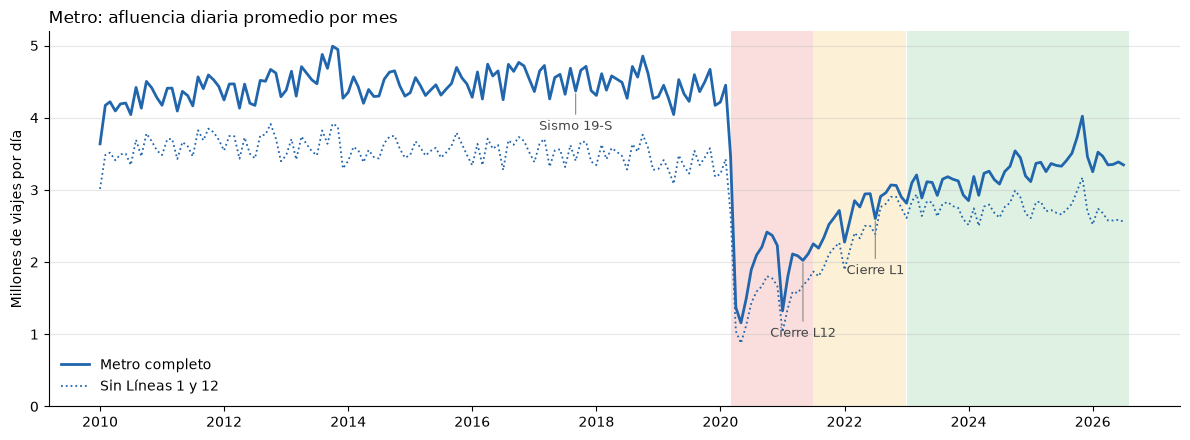

In [88]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

FIGURAS = RAIZ / "informe" / "figuras"
PERIODOS_M = [("2020-03-01", "2021-06-30", "#f4b6b6"), ("2021-07-01", "2022-12-31", "#f9e0a8"),
              ("2023-01-01", "2026-07-31", "#b9e0c3")]

serie = metro_mes.set_index("mes")
sin_mes = sin_cierres.resample("MS").mean()

fig, ax = plt.subplots(figsize=(12, 4.5))
for a, b_, c in PERIODOS_M:
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b_), color=c, alpha=.45, lw=0)
ax.plot(serie.index, serie.afluencia_diaria_promedio / 1e6, color="#2166ac", lw=2, label="Metro completo")
ax.plot(sin_mes.index, sin_mes / 1e6, color="#2166ac", lw=1.3, ls=":", label="Sin Líneas 1 y 12")
for fecha, texto, dy in [("2017-09-01", "Sismo 19-S", -28), ("2021-05-01", "Cierre L12", -55), ("2022-07-01", "Cierre L1", -40)]:
    y = serie.loc[fecha, "afluencia_diaria_promedio"] / 1e6
    ax.annotate(texto, (pd.Timestamp(fecha), y), xytext=(0, dy), textcoords="offset points", ha="center",
                fontsize=9, color="#444", arrowprops=dict(arrowstyle="-", color="#888", lw=.8))
ax.set_title("Metro: afluencia diaria promedio por mes", loc="left", fontsize=12)
ax.set_ylabel("Millones de viajes por día")
ax.set_ylim(0, None)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=.3)
ax.legend(frameon=False, loc="lower left")
plt.tight_layout()
fig.savefig(FIGURAS / "metro_limpio_mensual.png", dpi=150)
plt.show()

**2. Recuperación por línea.** Afluencia diaria promedio de cada año como porcentaje de 2019 (100 = igual que antes de la pandemia). Azul: por encima de 2019; rojo: por debajo.

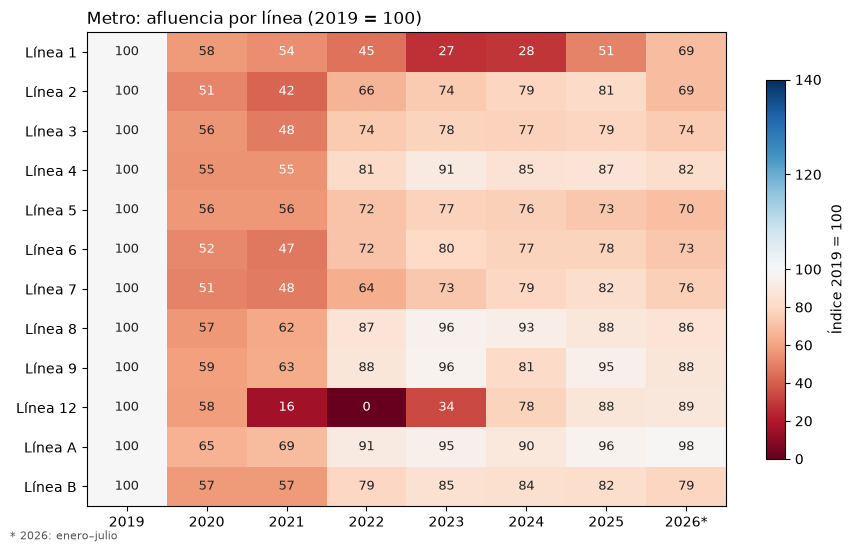

In [89]:
import numpy as np
from matplotlib.colors import TwoSlopeNorm

ld = linea_dia.assign(anio=linea_dia.fecha.dt.year)
prom = ld.pivot_table(index="linea", columns="anio", values="afluencia", aggfunc="mean")
indice_linea = (prom.div(prom[2019], axis=0) * 100).loc[:, 2019:2026].astype(float)
orden = sorted(indice_linea.index, key=lambda l: (len(l), l))           # Línea 1, 2, …, 9, 12, A, B
indice_linea = indice_linea.loc[[l for l in orden if l[-1].isdigit()] + [l for l in orden if not l[-1].isdigit()]]

fig, ax = plt.subplots(figsize=(9, 5.5))
im = ax.imshow(indice_linea, cmap="RdBu", norm=TwoSlopeNorm(vcenter=100, vmin=0, vmax=140), aspect="auto")
for i in range(indice_linea.shape[0]):
    for j in range(indice_linea.shape[1]):
        v = indice_linea.iat[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=9,
                    color="white" if abs(v - 100) > 45 else "#222")
ax.set_xticks(range(indice_linea.shape[1]), [str(c) + ("*" if c == 2026 else "") for c in indice_linea.columns])
ax.set_yticks(range(indice_linea.shape[0]), indice_linea.index)
ax.set_title("Metro: afluencia por línea (2019 = 100)", loc="left", fontsize=12)
fig.colorbar(im, ax=ax, shrink=.8, label="Índice 2019 = 100")
fig.text(0.01, 0.01, "* 2026: enero–julio", fontsize=8, color="#555")
plt.tight_layout()
fig.savefig(FIGURAS / "metro_lineas_indice.png", dpi=150)
plt.show()

**3. Estaciones cerradas por día.** Separa los cierres por la pandemia (abril–junio de 2020, en muchas líneas a la vez) de los cierres por obras (Líneas 12 y 1). El pico de enero de 2021 es el **incendio del Puesto Central de Control** (9-ene-2021), que detuvo las Líneas 1 a 6 varios días.

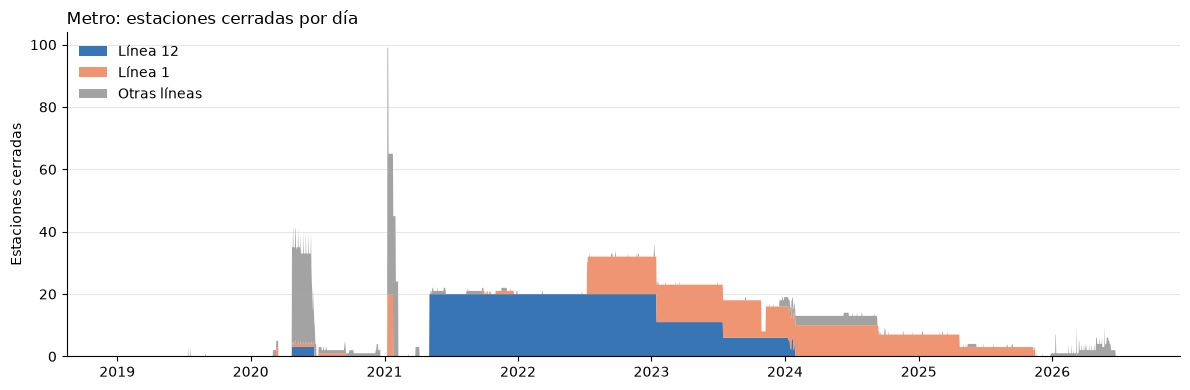

In [90]:
grupos_cierre = pd.DataFrame({
    "Línea 12": cerradas["Línea 12"],
    "Línea 1": cerradas["Línea 1"],
    "Otras líneas": cerradas.drop(columns=["Línea 12", "Línea 1"]).sum(axis=1),
}).loc["2019":]
# los días sin registro no son cierres
grupos_cierre = grupos_cierre[~grupos_cierre.index.isin(dias_sin_registro)]

fig, ax = plt.subplots(figsize=(12, 4))
ax.stackplot(grupos_cierre.index, grupos_cierre.T, labels=grupos_cierre.columns,
             colors=["#2166ac", "#ef8a62", "#999999"], alpha=.9)
ax.set_title("Metro: estaciones cerradas por día", loc="left", fontsize=12)
ax.set_ylabel("Estaciones cerradas")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=.3)
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
fig.savefig(FIGURAS / "metro_cierres.png", dpi=150)
plt.show()

### Errores encontrados en la limpieza (Metro)
Resumen de todos los problemas detectados en los pasos anteriores, cuántos registros afectaron y qué se decidió.

In [91]:
tabla_errores_metro = pd.DataFrame(errores, columns=["paso", "error encontrado", "registros", "decisión"])
pd.set_option("display.max_colwidth", 120)
tabla_errores_metro

,paso,error encontrado,registros,decisión
0,1. Codificación,Línea escrita 'LÃ­nea N' (2021–2023) y 'Linea N' (resto de años),171795,Se repara y se unifica a 'Línea N'
1,1. Codificación,Nombre de estación con mojibake ('CatÃ³lica'),379245,Se repara con ftfy
2,2. Estaciones,'Gómez Farias' en vez de 'Gómez Farías' (desde 2023-06),1157,Se unifica a la escritura anterior
3,2. Estaciones,'Peñón viejo' en vez de 'Peñón Viejo' (desde 2023-06),1157,Se unifica a la escritura anterior
4,3. Duplicados,"Línea B, dic-2020: 'Oceanía' aparece dos veces por día y falta 'Deportivo Oceanía'",31,"El 2.º registro (≈7 mil, igual que Deportivo Oceanía) se reasigna a esa estación"
5,5. Ceros,Línea 12: ceros antes de su inauguración (primer pasajero: 05-11-2012),20780,"No son faltantes: la estación no existía → vacío, estado 'no_existia'"
6,5. Ceros,"10 días con el sistema completo en ~0 (sismo 19-S 2017, contingencia mar-2016)",1950,"Servicio gratuito sin conteo → vacío, estado 'sin_registro'"
7,5. Ceros,"Estación cerrada (COVID 2020, cierres de L12 y L1, obras)",39667,"Es un 0 real → se conserva, estado 'cerrada'"
8,6. Atípicos,Días > 4× la mediana de 29 días de la estación,90,"Se conservan: eventos masivos (12-dic, conciertos, marchas) y reaperturas"


### Interpretación
- **Caída:** en mayo de 2020 la afluencia diaria fue el **26 % de 2019** (−74 %), y el promedio de 2020 fue el 56 %. **Apoya H1** (caída mayor al 50 %).
- **Recuperación incompleta:** en 2025 el Metro está en **79 %** de 2019. Aun **sin las Líneas 1 y 12** (quitando sus cierres) llega solo a **~83 %**. Los cierres explican una parte, pero la demanda no ha vuelto. Contrasta con el Metrobús, que ya supera 2019.
- **Por línea (2025):** la recuperación es desigual. Las Líneas A (96), 9 (95), 8 (88), 12 (88) y 4 (87) están cerca de 2019; las Líneas 2, 3, 5, 6 y 7 siguen en 73–82. Queda por revisar si esto se relaciona con el teletrabajo en las zonas que atienden.
- **Para usar en la integración:** la variable es `afluencia_diaria_promedio` de `metro_mes`, **no** la suma mensual (hay meses con días sin registro). Para comparar la pandemia sin el efecto de las obras, excluir `linea_1` y `linea_12` entre 2021-05 y 2025-12.

---
## Casos positivos de COVID-19 (CDMX)

**Rol:** variable de **control** que mide la intensidad de la pandemia, para relacionarla con la movilidad, la seguridad y la economía.

**Fuente:** `casos_positivos_covid_19_ciudad_de_mexico.csv` (Portal de Datos Abiertos CDMX). Tiene una fila por **día de toma de muestra**, con las pruebas y los positivos totales (todas las personas atendidas en la CDMX) y los de **residentes** de la CDMX (`_cdmx`). Para el proyecto se usan los de residentes, porque las demás fuentes miden a la ciudad.

**Salidas** (`data/interim/`): `covid_dia`, `covid_semana` (misma semana ISO que el semáforo, para unirlos) y `covid_mes`.

In [92]:
import sys
from pathlib import Path
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = RAIZ / "data" / "raw"
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
from src.clean.catalogos import guardar

errores_covid = []   # (paso, error encontrado, registros afectados, decisión)

covid_raw = pd.read_csv(RAW / "covid" / "casos_positivos_covid_19_ciudad_de_mexico.csv")
print(covid_raw.shape)
print(covid_raw.dtypes.to_string())
print("Vacíos:", covid_raw.isna().sum().sum())
covid_raw.head()

(1113, 7)
fecha_toma_muestra            str
pruebas_totales             int64
positivos_totales           int64
pruebas_totales_cdmx        int64
positivos_totales_cdmx      int64
tasa_positividad          float64
tasa_positividad_cdmx     float64
Vacíos: 0


,fecha_toma_muestra,pruebas_totales,positivos_totales,pruebas_totales_cdmx,positivos_totales_cdmx,tasa_positividad,tasa_positividad_cdmx
0,2020-03-05,69,1,52,1,0.014493,0.019231
1,2020-03-13,57,2,46,1,0.035088,0.021739
2,2020-03-19,67,3,67,3,0.044776,0.044776
3,2020-03-24,66,1,60,1,0.015152,0.016667
4,2020-03-26,54,1,50,1,0.018519,0.020000


### Paso 1 — Fechas y días faltantes

In [93]:
covid = covid_raw.rename(columns={"fecha_toma_muestra": "fecha"})
covid["fecha"] = pd.to_datetime(covid["fecha"], format="%Y-%m-%d")
print(f"Periodo: {covid.fecha.min().date()} → {covid.fecha.max().date()} · duplicados: {covid.fecha.duplicated().sum()}")

calendario = pd.date_range(covid.fecha.min(), covid.fecha.max())
faltantes = calendario.difference(covid.fecha)
print(f"Días faltantes: {len(faltantes)} →", sorted({f.strftime('%Y-%m') for f in faltantes}))
covid[covid.fecha < "2020-04-08"]

Periodo: 2020-03-05 → 2023-04-08 · duplicados: 0
Días faltantes: 17 → ['2020-03']


,fecha,pruebas_totales,positivos_totales,pruebas_totales_cdmx,positivos_totales_cdmx,tasa_positividad,tasa_positividad_cdmx
0,2020-03-05,69,1,52,1,0.014493,0.019231
1,2020-03-13,57,2,46,1,0.035088,0.021739
2,2020-03-19,67,3,67,3,0.044776,0.044776
3,2020-03-24,66,1,60,1,0.015152,0.016667
4,2020-03-26,54,1,50,1,0.018519,0.020000
5,2020-03-27,32,4,30,4,0.125000,0.133333
6,2020-03-28,5,1,3,1,0.200000,0.333333
7,2020-03-29,16,5,16,6,0.312500,0.375000
8,2020-03-30,49,3,46,2,0.061224,0.043478
9,2020-03-31,26,4,24,4,0.153846,0.166667


Los 17 días faltantes son **todos de marzo de 2020**, cuando casi no se hacían pruebas: los días que sí aparecen tienen entre 5 y 69 pruebas y de 1 a 5 positivos. Un día que no aparece es un día **sin muestras tomadas**, así que se rellena con **0** y se marca (`dia_agregado`).

Además, las pruebas saltan de 69 a 2,337 el **5-abr-2020**: ese día empieza el registro masivo. Los días anteriores se marcan con `arranque = True` porque no son comparables con el resto de la serie.

In [94]:
errores_covid.append(("1. Fechas", "Días de marzo de 2020 sin fila (sin muestras tomadas)", len(faltantes),
                      "Se agregan con 0 y se marcan dia_agregado = True"))
conteos = ["pruebas_totales", "positivos_totales", "pruebas_totales_cdmx", "positivos_totales_cdmx"]
covid = covid.set_index("fecha").reindex(calendario).rename_axis("fecha").reset_index()
covid["dia_agregado"] = covid["fecha"].isin(faltantes)
covid[conteos] = covid[conteos].fillna(0).astype(int)

INICIO_REGISTRO = pd.Timestamp("2020-04-05")
covid["arranque"] = covid["fecha"] < INICIO_REGISTRO
errores_covid.append(("1. Fechas", "Antes del 5-abr-2020 hay < 70 pruebas por día (arranque del registro)",
                      int(covid.arranque.sum()), "Se conservan y se marcan arranque = True"))
print(f"{len(covid):,} días · agregados: {covid.dia_agregado.sum()} · en arranque: {covid.arranque.sum()}")

1,130 días · agregados: 17 · en arranque: 31


### Paso 2 — Consistencia entre columnas
Reglas: los positivos no pueden superar a las pruebas, los residentes no pueden superar al total y la tasa de positividad debe ser positivos ÷ pruebas.

In [95]:
reglas = {
    "positivos > pruebas (total)": covid.positivos_totales > covid.pruebas_totales,
    "positivos > pruebas (residentes)": covid.positivos_totales_cdmx > covid.pruebas_totales_cdmx,
    "pruebas residentes > pruebas total": covid.pruebas_totales_cdmx > covid.pruebas_totales,
    "positivos residentes > positivos total": covid.positivos_totales_cdmx > covid.positivos_totales,
    "negativos": (covid[conteos] < 0).any(axis=1),
}
con_dato = ~covid.dia_agregado
for nombre, regla in [("tasa_positividad", covid.positivos_totales / covid.pruebas_totales),
                      ("tasa_positividad_cdmx", covid.positivos_totales_cdmx / covid.pruebas_totales_cdmx)]:
    reglas[f"{nombre} ≠ positivos ÷ pruebas"] = con_dato & ((covid[nombre] - regla).abs() > 1e-9)
for nombre, m in reglas.items():
    print(f"{nombre:<45} {m.sum()}")
covid[reglas["positivos residentes > positivos total"]]

positivos > pruebas (total)                   0
positivos > pruebas (residentes)              0
pruebas residentes > pruebas total            0
positivos residentes > positivos total        1
negativos                                     0
tasa_positividad ≠ positivos ÷ pruebas        0
tasa_positividad_cdmx ≠ positivos ÷ pruebas   0


,fecha,pruebas_totales,positivos_totales,pruebas_totales_cdmx,positivos_totales_cdmx,tasa_positividad,tasa_positividad_cdmx,dia_agregado,arranque
24,2020-03-29,16,5,16,6,0.3125,0.375,False,True


Solo hay **una fila inconsistente**: el 29-mar-2020 hay 6 positivos residentes y 5 en total, lo cual es imposible porque los residentes son parte del total. Como no se sabe cuál de los dos está mal, se ajusta el total al valor de los residentes (6). Es el cambio mínimo, y en esa fecha la diferencia es de un caso. Las tasas del archivo están bien calculadas.

In [96]:
m = reglas["positivos residentes > positivos total"]
errores_covid.append(("2. Consistencia", "29-mar-2020: positivos de residentes (6) > positivos totales (5)", int(m.sum()),
                      "Se sube el total al valor de residentes (cambio mínimo de 1 caso)"))
covid.loc[m, "positivos_totales"] = covid.loc[m, "positivos_totales_cdmx"]

# las tasas se recalculan (quedan vacías en los días sin pruebas, en vez de dividir entre 0)
covid["tasa_positividad"] = (covid.positivos_totales / covid.pruebas_totales.where(covid.pruebas_totales > 0)).round(4)
covid["tasa_positividad_cdmx"] = (covid.positivos_totales_cdmx / covid.pruebas_totales_cdmx.where(covid.pruebas_totales_cdmx > 0)).round(4)
print("Filas que siguen violando alguna regla:",
      int(((covid.positivos_totales_cdmx > covid.positivos_totales) | (covid.positivos_totales > covid.pruebas_totales)).sum()))

Filas que siguen violando alguna regla: 0


### Paso 3 — Efecto del día de la semana y atípicos

In [97]:
dias_semana = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]
reg = covid[~covid.arranque]
por_dia_semana = reg.groupby(reg.fecha.dt.dayofweek)[["pruebas_totales_cdmx", "positivos_totales_cdmx"]].mean().round(0)
por_dia_semana.index = dias_semana
print(por_dia_semana.to_string())

s = reg.set_index("fecha").pruebas_totales_cdmx
ratio_covid = s / s.rolling(29, center=True, min_periods=10).median()
print("\nDías con > 3 veces las pruebas normales (ya en registro masivo):")
print(pd.DataFrame({"pruebas": s[ratio_covid > 3], "× mediana": ratio_covid[ratio_covid > 3].round(1)}).to_string())

     pruebas_totales_cdmx  positivos_totales_cdmx
lun                6966.0                  1848.0
mar                7362.0                  1948.0
mié                7388.0                  1924.0
jue                7119.0                  1832.0
vie                6728.0                  1714.0
sáb                2510.0                   623.0
dom                1702.0                   417.0

Días con > 3 veces las pruebas normales (ya en registro masivo):
Empty DataFrame
Columns: [pruebas, × mediana]
Index: []


- **Fines de semana:** el domingo se toman unas 4 veces menos muestras que entre semana. No es un error, pero hace que la serie diaria "serrucho". Por eso se agrega un **promedio móvil de 7 días** y el análisis se hace por **semana**.
- **Atípicos:** una vez iniciado el registro masivo (5-abr-2020) no hay días con más de 3 veces las pruebas normales. El único salto de la serie es el del arranque, que ya está marcado. No se anula ningún valor.

In [98]:
errores_covid.append(("3. Día de la semana", "El domingo tiene ~4 veces menos pruebas que entre semana", int((covid.fecha.dt.dayofweek >= 5).sum()),
                      "No es error: se agrega promedio móvil de 7 días y se analiza por semana"))
for c in ["pruebas_totales_cdmx", "positivos_totales_cdmx"]:
    covid[f"{c}_7d"] = covid[c].rolling(7, min_periods=7).mean().round(1)

### Paso 4 — Tablas semanal y mensual
Las tasas se calculan con las **sumas** del periodo (positivos ÷ pruebas), no como promedio de las tasas diarias, porque así un domingo con pocas pruebas no pesa lo mismo que un lunes.

La serie termina el **8-abr-2023**. La última semana y el último mes quedan incompletos y se marcan. Después de esa fecha no hay dato (no significa 0 casos): al integrar hay que dejarlo **vacío**.

In [99]:
def agregar(df, periodo):
    g = df.groupby(periodo).agg(dias=("fecha", "size"), **{c: (c, "sum") for c in conteos})
    g["tasa_positividad"] = (g.positivos_totales / g.pruebas_totales).round(4)
    g["tasa_positividad_cdmx"] = (g.positivos_totales_cdmx / g.pruebas_totales_cdmx).round(4)
    return g

covid["semana"] = covid.fecha.dt.strftime("%G-W%V")                       # igual que en el semáforo
covid_semana = agregar(covid, "semana").reset_index()
covid_semana["fecha"] = pd.to_datetime(covid_semana.semana + "-1", format="%G-W%V-%u")   # lunes de la semana
covid_semana["semana_incompleta"] = covid_semana.dias < 7
covid_semana = covid_semana[["semana", "fecha", "dias", "semana_incompleta", *conteos, "tasa_positividad", "tasa_positividad_cdmx"]]

covid["mes"] = covid.fecha.dt.to_period("M").dt.to_timestamp()
covid_mes = agregar(covid, "mes").reset_index()
covid_mes["mes_incompleto"] = covid_mes.dias < covid_mes.mes.dt.days_in_month
covid_mes = covid_mes[["mes", "dias", "mes_incompleto", *conteos, "tasa_positividad", "tasa_positividad_cdmx"]]

covid_dia = covid[["fecha", *conteos, "tasa_positividad", "tasa_positividad_cdmx",
                   "pruebas_totales_cdmx_7d", "positivos_totales_cdmx_7d", "dia_agregado", "arranque"]]

print("Semanas incompletas:", covid_semana.loc[covid_semana.semana_incompleta, "semana"].tolist())
print("Meses incompletos:", covid_mes.loc[covid_mes.mes_incompleto, "mes"].dt.strftime("%Y-%m").tolist())
print("¿Cuadran los totales?", all(covid_dia[c].sum() == covid_semana[c].sum() == covid_mes[c].sum() for c in conteos),
      f"({covid_dia.positivos_totales_cdmx.sum():,} positivos de residentes)")
guardar(covid_dia, "covid_dia")
guardar(covid_semana, "covid_semana")
guardar(covid_mes, "covid_mes")
covid_semana.head()

Semanas incompletas: ['2020-W10', '2023-W14']
Meses incompletos: ['2020-03', '2023-04']
¿Cuadran los totales? True (1,617,973 positivos de residentes)
  → data/interim/covid_dia.csv / .parquet (1,130 filas)
  → data/interim/covid_semana.csv / .parquet (162 filas)
  → data/interim/covid_mes.csv / .parquet (38 filas)


,semana,fecha,dias,semana_incompleta,pruebas_totales,positivos_totales,pruebas_totales_cdmx,positivos_totales_cdmx,tasa_positividad,tasa_positividad_cdmx
0,2020-W10,2020-03-02,4,True,69,1,52,1,0.0145,0.0192
1,2020-W11,2020-03-09,7,False,57,2,46,1,0.0351,0.0217
2,2020-W12,2020-03-16,7,False,67,3,67,3,0.0448,0.0448
3,2020-W13,2020-03-23,7,False,173,13,159,13,0.0751,0.0818
4,2020-W14,2020-03-30,7,False,2574,568,2365,518,0.2207,0.2190


### Resultado

In [100]:
anual_covid = covid_mes.groupby(covid_mes.mes.dt.year)[conteos].sum()
anual_covid["tasa_positividad_cdmx"] = (anual_covid.positivos_totales_cdmx / anual_covid.pruebas_totales_cdmx * 100).round(1)
anual_covid.index.name = "año"
display(anual_covid.style.format({c: "{:,.0f}" for c in conteos} | {"tasa_positividad_cdmx": "{:.1f} %"}))

pico = covid_semana.loc[covid_semana.positivos_totales_cdmx.idxmax()]
print(f"Semana con más positivos: {pico.semana} ({pico.fecha:%d-%b-%Y}) → {pico.positivos_totales_cdmx:,} positivos, "
      f"positividad {pico.tasa_positividad_cdmx:.0%}")

,pruebas_totales,positivos_totales,pruebas_totales_cdmx,positivos_totales_cdmx,tasa_positividad_cdmx
año,,,,,
2020,"1,174,276","363,198","1,008,610","309,075",30.6 %
2021,"3,489,450","568,878","3,033,269","499,470",16.5 %
2022,"2,216,146","800,120","1,996,273","727,607",36.4 %
2023,"227,827","88,713","207,025","81,821",39.5 %


Semana con más positivos: 2022-W03 (17-Jan-2022) → 59,840 positivos, positividad 46%


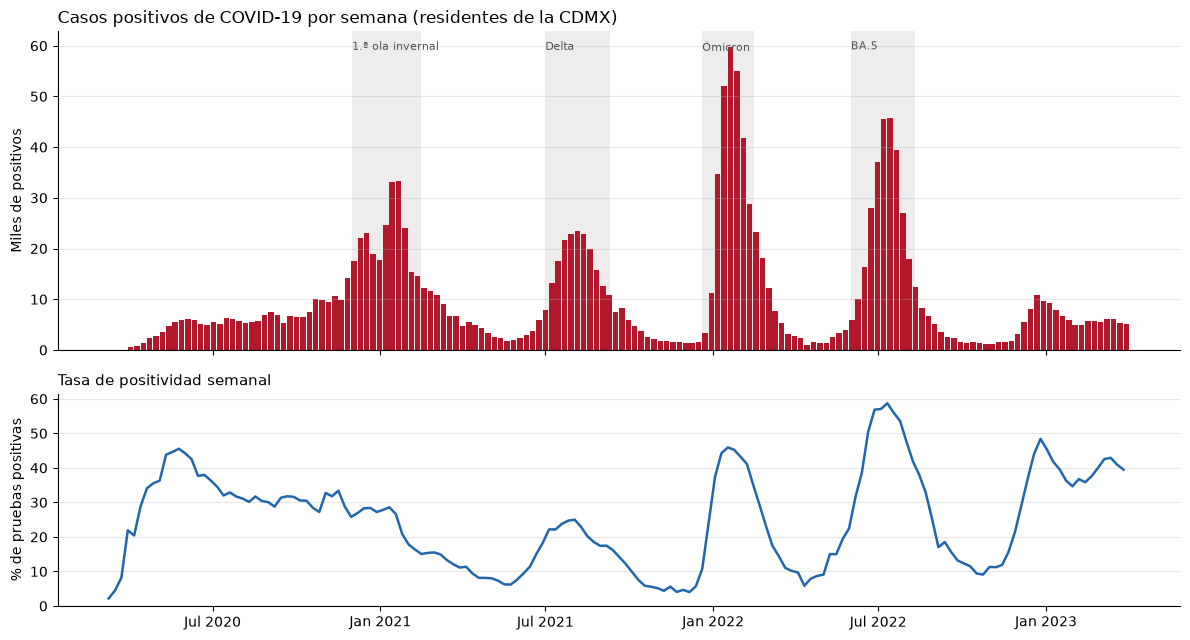

In [101]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

FIGURAS = RAIZ / "informe" / "figuras"
completas = covid_semana[~covid_semana.semana_incompleta]
olas = [("2020-12-01", "2021-02-15", "1.ª ola invernal"), ("2021-07-01", "2021-09-10", "Delta"),
        ("2021-12-20", "2022-02-15", "Ómicron"), ("2022-06-01", "2022-08-10", "BA.5")]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True, height_ratios=[3, 2])
ax1.bar(completas.fecha, completas.positivos_totales_cdmx / 1e3, width=6, color="#b2182b", align="edge")
for a, b, texto in olas:
    ax1.axvspan(pd.Timestamp(a), pd.Timestamp(b), color="#dddddd", alpha=.5, lw=0, zorder=0)
    ax1.text(pd.Timestamp(a), ax1.get_ylim()[1] * .97, texto, fontsize=8, color="#555", va="top")
ax1.set_title("Casos positivos de COVID-19 por semana (residentes de la CDMX)", loc="left", fontsize=12)
ax1.set_ylabel("Miles de positivos")

ax2.plot(completas.fecha, completas.tasa_positividad_cdmx * 100, color="#2166ac", lw=1.8)
ax2.set_title("Tasa de positividad semanal", loc="left", fontsize=11)
ax2.set_ylabel("% de pruebas positivas")
ax2.set_ylim(0, None)
for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=.3)
ax2.xaxis.set_major_locator(mdates.MonthLocator([1, 7]))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.tight_layout()
fig.savefig(FIGURAS / "covid_semanal.png", dpi=150)
plt.show()

**Lectura:** hay cuatro olas claras. La de invierno 2020–2021 llegó a ~33 mil positivos por semana, Delta (verano de 2021) a ~23 mil, **Ómicron** (enero de 2022) al máximo de la serie con ~60 mil y BA.5 (verano de 2022) a ~46 mil. Hubo una ola menor a finales de 2022. La **positividad** fue de 45 % a mitad de 2020, 46 % con Ómicron y 59 % con BA.5: en esos momentos muchos contagios no se detectaban, así que los positivos **subestiman** los contagios reales. Como control conviene usar la **tasa de positividad** junto con los positivos.

⚠️ La serie termina el 8-abr-2023. Para el periodo post-pandemia (2023–2024) no hay dato de casos: al integrar se deja vacío (no 0), y el semáforo cubre hasta junio de 2023.

### Errores encontrados en la limpieza (COVID)

In [102]:
pd.DataFrame(errores_covid, columns=["paso", "error encontrado", "registros", "decisión"])

,paso,error encontrado,registros,decisión
0,1. Fechas,Días de marzo de 2020 sin fila (sin muestras tomadas),17,Se agregan con 0 y se marcan dia_agregado = True
1,1. Fechas,Antes del 5-abr-2020 hay < 70 pruebas por día (arranque del registro),31,Se conservan y se marcan arranque = True
2,2. Consistencia,29-mar-2020: positivos de residentes (6) > positivos totales (5),1,Se sube el total al valor de residentes (cambio mínimo de 1 caso)
3,3. Día de la semana,El domingo tiene ~4 veces menos pruebas que entre semana,323,No es error: se agrega promedio móvil de 7 días y se analiza por semana
